In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
PROJECT_PATH = "/content/drive/MyDrive/DataSet"

print(PROJECT_PATH)

/content/drive/MyDrive/DataSet


In [7]:
import os

print(os.listdir(PROJECT_PATH))

['processed', 'metadata', 'documentation']


In [4]:
!pip install -q opencv-python pandas numpy matplotlib seaborn scikit-learn pillow openpyxl psycopg2-binary sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 40.5 MB/s eta 0:00:00


In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
import os

BASE_PATH = "/content/drive/MyDrive/DataSet"

folders = [
    "processed",
    "processed/images",
    "processed/images/train",
    "processed/images/val",
    "processed/images/test",
    "processed/structured",
    "metadata",
    "documentation"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("All required folders created successfully!")

All required folders created successfully!


In [10]:
import os

BASE_PATH = "/content/drive/MyDrive/DataSet"

folders = [
    "processed",
    "processed/images",
    "processed/images/train",
    "processed/images/val",
    "processed/images/test",
    "processed/structured",
    "metadata",
    "documentation"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("All required folders created successfully!")

All required folders created successfully!


In [11]:
import os

print("MyDrive contents:")
print(os.listdir("/content/drive/MyDrive"))

MyDrive contents:
['23RH1A6611', 'CV', 'infosys AI certificate.pdf', 'GOOGLE CLOUD(GEN AI).pdf', 'oracle1.pdf', 'Resume2.pdf', 'Colab Notebooks', 'AI_Powered_Soil_Analytics_System', 'DataSet']


In [12]:
import os

DATASET_PATH = "/content/drive/MyDrive/DataSet"

print("Does DataSet exist?", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("\nDataSet contents:")
    print(os.listdir(DATASET_PATH))

Does DataSet exist? True

DataSet contents:
['processed', 'metadata', 'documentation']


In [13]:
RAW_PATH = "/content/drive/MyDrive/DataSet/raw"

print("Does raw exist?", os.path.exists(RAW_PATH))

if os.path.exists(RAW_PATH):
    print("\nRaw contents:")
    print(os.listdir(RAW_PATH))

Does raw exist? False


In [14]:
ORIGINAL_PATH = "/content/drive/MyDrive/DataSet/raw/Original-Dataset"

print("Does Original-Dataset exist?", os.path.exists(ORIGINAL_PATH))

if os.path.exists(ORIGINAL_PATH):
    print("\nOriginal-Dataset contents:")
    print(os.listdir(ORIGINAL_PATH))

Does Original-Dataset exist? False


In [15]:
import os

MYDRIVE = "/content/drive/MyDrive"

print("Searching for folders named 'raw'...\n")

for root, dirs, files in os.walk(MYDRIVE):
    if "raw" in dirs:
        raw_path = os.path.join(root, "raw")
        print(raw_path)

Searching for folders named 'raw'...

/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw


In [16]:
print("Searching for Original-Dataset...\n")

for root, dirs, files in os.walk(MYDRIVE):
    if "Original-Dataset" in dirs:
        original_path = os.path.join(root, "Original-Dataset")
        print(original_path)

Searching for Original-Dataset...



In [17]:
print("Searching for Samples EJP Probesfield.xlsx...\n")

for root, dirs, files in os.walk(MYDRIVE):
    for file in files:
        if file.lower() == "samples ejp probefield.xlsx":
            print(os.path.join(root, file))

Searching for Samples EJP Probesfield.xlsx...

/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Samples EJP Probefield.xlsx


In [18]:
import os

BASE_PATH = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet"
RAW_PATH = os.path.join(BASE_PATH, "raw")

print("RAW PATH:")
print(RAW_PATH)

print("\nFiles and folders inside raw:")

for item in os.listdir(RAW_PATH):
    full_path = os.path.join(RAW_PATH, item)

    if os.path.isdir(full_path):
        print("📁", item)
    else:
        print("📄", item)

RAW PATH:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw

Files and folders inside raw:
📄 Samples EJP Probefield.xlsx
📁 Orignal-Dataset


In [19]:
import os

BASE_PATH = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet"
RAW_PATH = os.path.join(BASE_PATH, "raw")

print("Files currently inside raw:\n")

for file in os.listdir(RAW_PATH):
    print(repr(file))

Files currently inside raw:

'Samples EJP Probefield.xlsx'
'Orignal-Dataset'


In [20]:
import os
import pandas as pd

excel_files = [
    f for f in os.listdir(RAW_PATH)
    if f.lower().endswith((".xlsx", ".xls"))
]

print("Excel files found:")
for f in excel_files:
    print(f)

Excel files found:
Samples EJP Probefield.xlsx


In [21]:
if len(excel_files) == 0:
    print("No Excel file found in the raw folder.")
else:
    EXCEL_PATH = os.path.join(RAW_PATH, excel_files[0])

    print("Using:")
    print(EXCEL_PATH)

    excel_file = pd.ExcelFile(EXCEL_PATH)

    print("\nAvailable sheets:")
    for sheet in excel_file.sheet_names:
        print("-", sheet)

Using:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Samples EJP Probefield.xlsx

Available sheets:
- Samples
- Methods


In [22]:
for sheet in excel_file.sheet_names:

    df = pd.read_excel(
        EXCEL_PATH,
        sheet_name=sheet
    )

    print("\n" + "=" * 60)
    print("SHEET:", sheet)
    print("ROWS:", df.shape[0])
    print("COLUMNS:", df.shape[1])

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())


SHEET: Samples
ROWS: 163
COLUMNS: 2219

Column names:
['NUMBER', 'PROJECT', 'Comment', 'SAMPLING DATE', 'SITE', 'PLOT', 'SITE2', 'CROP', 'PREVIOUS CROP', 'DEPTH (cm)', 'Coord1', 'Coord2', 'Moisture (%dw)', 'BD (g/cm3)', 'Labnumber', 'Label', 'Coarse sand (%)', 'Fine sand (%)', 'Silt (%)', 'Clay (%)', 'Texture Class', 'pH (Ext 1:2.5)', 'EC (Ext 1:5) (mS/cm)', 'Carbonate (% CaCO3)', 'orgánic-C\xa0 (%)', 'organic Matter (%)', 'total-N (%)', 'avail-P (mg/kg)', 'avail-K (mg/kg)', 'SAMPLE', 'XRFs-S', 'XRFs-K', 'XRFs-Ca', 'XRFs-Ti', 'XRFs-V', 'XRFs-Cr', 'XRFs-Mn', 'XRFs-Fe', 'XRFs-Co', 'XRFs-Ni', 'XRFs-Cu', 'XRFs-Zn', 'XRFs-As', 'XRFs-Se', 'XRFs-Rb', 'XRFs-Sr', 'XRFs-Zr', 'XRFs-Mo', 'XRFs-Cd', 'XRFs-Sn', 'XRFs-Sb', 'XRFs-Ba', 'XRFs-Pb', 'XRFs-Th', 'XRFs-U', 'XRFm-Ca', 'XRFm-Mn', 'XRFm-Fe', 'XRFm-Mg', 'XRFm-Al', 'XRFm-Bal', 'XRFm-Si', 'XRFm-P', 'XRFm-Cl', 'XRFm-Nb', 'XRFm-Bi', 'Unnamed: 66', 'Unnamed: 67', 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 36

,NUMBER,PROJECT,Comment,SAMPLING DATE,SITE,PLOT,SITE2,CROP,PREVIOUS CROP,DEPTH (cm),...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,1,PBF,NaN,2022-01-26 00:00:00,"La Hampa farm, Coria del Río",IRNAS1_CORN deltaC centro,NaN,MAIZE,MAIZE,5-10,...,0.100666,0.1004,0.09963,0.09929,0.099189,0.099366,0.099709,0.099607,0.099647,0.099544
1,2,PBF,NaN,2022-01-26 00:00:00,"La Hampa farm, Coria del Río",IRNAS_2_RAIN EXCLUSION,Near concrete sink,Wheat,NaN,5-10,...,0.127261,0.125996,0.123887,0.122636,0.121421,0.120158,0.120111,0.120282,0.120821,0.120874
2,3,PBF,NaN,2022-01-26 00:00:00,"La Hampa farm, Coria del Río",IRNAS3_Lost triangle,NaN,Fallow,NaN,5-10,...,0.112045,0.112057,0.111927,0.111969,0.113885,0.115348,0.114605,0.113089,0.11047,0.108419
3,4,PBF,NaN,2022-01-26 00:00:00,"La Hampa farm, Coria del Río",IRNAS4_Urban orchard,Houses Corner,Wheat,NaN,5-10,...,0.141686,0.142685,0.142583,0.142977,0.142852,0.142391,0.142177,0.141453,0.141013,0.14098
4,5,PBF,NaN,2022-01-26 00:00:00,"La Hampa farm, Coria del Río",IRNAS5_Urban orchard,behind the transformer,Wheat,NaN,5-10,...,0.107113,0.107308,0.107389,0.107079,0.108113,0.109155,0.109286,0.110508,0.11166,0.111664



SHEET: Methods
ROWS: 3
COLUMNS: 2219

Column names:
['NUMBER', 'PROJECT', 'Comment', 'SAMPLING DATE', 'SITE', 'PLOT', 'SITE2', 'CROP', 'PREVIOUS CROP', 'DEPTH (cm)', 'Coord1', 'Coord2', 'Moisture (%dw)', 'BD (g/cm3)', 'Labnumber', 'Label', 'Coarse sand (%)', 'Fine sand (%)', 'Silt (%)', 'Clay (%)', 'Texture Class', 'pH (Ext 1:2.5)', 'EC (Ext 1:5) (mS/cm)', 'Carbonate (% CaCO3)', 'orgánic-C\xa0 (%)', 'organic Matter (%)', 'total-N (%)', 'avail-P (mg/kg)', 'avail-K (mg/kg)', 'SAMPLE', 'XRFs-S', 'XRFs-K', 'XRFs-Ca', 'XRFs-Ti', 'XRFs-V', 'XRFs-Cr', 'XRFs-Mn', 'XRFs-Fe', 'XRFs-Co', 'XRFs-Ni', 'XRFs-Cu', 'XRFs-Zn', 'XRFs-As', 'XRFs-Se', 'XRFs-Rb', 'XRFs-Sr', 'XRFs-Zr', 'XRFs-Mo', 'XRFs-Cd', 'XRFs-Sn', 'XRFs-Sb', 'XRFs-Ba', 'XRFs-Pb', 'XRFs-Th', 'XRFs-U', 'XRFm-Ca', 'XRFm-Mn', 'XRFm-Fe', 'XRFm-Mg', 'XRFm-Al', 'XRFm-Bal', 'XRFm-Si', 'XRFm-P', 'XRFm-Cl', 'XRFm-Nb', 'XRFm-Bi', 'Unnamed: 66', 'Unnamed: 67', 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367,

,NUMBER,PROJECT,Comment,SAMPLING DATE,SITE,PLOT,SITE2,CROP,PREVIOUS CROP,DEPTH (cm),...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,NaN,NaN,NaN,mm/dd/yy,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Load the Samples sheet
df = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Samples"
)

print("Dataset shape:", df.shape)

# Search for important soil-related columns
keywords = [
    "nitrogen",
    "nitrogen (%)",
    "phosphorus",
    "phosphorus (%)",
    "potassium",
    "potassium (%)",
    "moisture",
    "organic",
    "carbon",
    "ph",
    "texture",
    "clay",
    "sand",
    "silt"
]

print("\nRelevant columns found:\n")

for keyword in keywords:

    matches = [
        col for col in df.columns
        if keyword.lower() in str(col).lower()
    ]

    if matches:
        print("\n" + keyword.upper())
        for col in matches:
            print("  -", col)

Dataset shape: (163, 2219)

Relevant columns found:


MOISTURE
  - Moisture (%dw)

ORGANIC
  - organic Matter (%)

CARBON
  - Carbonate (% CaCO3)

PH
  - pH (Ext 1:2.5)

TEXTURE
  - Texture Class

CLAY
  - Clay (%)

SAND
  - Coarse sand (%)
  - Fine sand (%)

SILT
  - Silt (%)


In [24]:
# Show all columns related to the required soil parameters

important_words = [
    "nitrogen",
    "phosphorus",
    "potassium",
    "moisture",
    "organic",
    "carbon",
    "ph",
    "texture"
]

relevant_columns = []

for col in df.columns:
    col_text = str(col).lower()

    if any(word in col_text for word in important_words):
        relevant_columns.append(col)

print("Number of relevant columns:", len(relevant_columns))

print("\nRelevant columns:")
for i, col in enumerate(relevant_columns):
    print(i, ":", col)

Number of relevant columns: 5

Relevant columns:
0 : Moisture (%dw)
1 : Texture Class
2 : pH (Ext 1:2.5)
3 : Carbonate (% CaCO3)
4 : organic Matter (%)


In [25]:
inspection = pd.DataFrame({
    "Column": relevant_columns,
    "Data_Type": [df[col].dtype for col in relevant_columns],
    "Missing_Count": [df[col].isna().sum() for col in relevant_columns],
    "Missing_Percentage": [
        round(df[col].isna().mean() * 100, 2)
        for col in relevant_columns
    ],
    "Unique_Values": [df[col].nunique() for col in relevant_columns]
})

display(inspection)

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,Moisture (%dw),float64,2,1.23,160
1,Texture Class,object,15,9.20,12
2,pH (Ext 1:2.5),float64,15,9.20,104
3,Carbonate (% CaCO3),float64,15,9.20,129
4,organic Matter (%),float64,15,9.20,133


In [26]:
for col in relevant_columns:
    print("\n" + "=" * 70)
    print("COLUMN:", col)
    print("DATA TYPE:", df[col].dtype)
    print("SAMPLE VALUES:")
    print(df[col].dropna().head(10).tolist())


COLUMN: Moisture (%dw)
DATA TYPE: float64
SAMPLE VALUES:
[15.4946910506282, 15.6668263405562, 13.377566574016, 17.3779591836735, 20.5089015312332, 21.3422998427515, 11.0506566604128, 11.9656609014014, 9.55019857763, 14.2504409171076]

COLUMN: Texture Class
DATA TYPE: object
SAMPLE VALUES:
['Sandy loam', 'Loam', 'Sandy-clay-loam', 'Loam', 'Clay loam', 'Silty Clay loam', 'Loamy sand', 'Sandy loam', 'Sandy loam', 'Sandy-clay-loam']

COLUMN: pH (Ext 1:2.5)
DATA TYPE: float64
SAMPLE VALUES:
[7.65, 7.36, 7.27, 7.2, 7.36, 7.46, 7.89, 7.33, 7.4, 7.46]

COLUMN: Carbonate (% CaCO3)
DATA TYPE: float64
SAMPLE VALUES:
[11.4, 18.8, 11.3, 9.9, 9.9, 14.8, 5.9, 3.8, 6.3, 24.8]

COLUMN: organic Matter (%)
DATA TYPE: float64
SAMPLE VALUES:
[1.72, 1.86, 1.78, 2.44, 2.78, 2.74, 1.08, 1.21, 1.56, 1.55]


In [27]:
# Recreate the clean soil dataset

soil_df = df[
    [
        "NUMBER",
        "PROJECT",
        "SITE",
        "PLOT",
        "CROP",
        "PREVIOUS CROP",
        "DEPTH (cm)",
        "Moisture (%dw)",
        "Texture Class",
        "pH (Ext 1:2.5)",
        "Carbonate (% CaCO3)",
        "organic Matter (%)"
    ]
].copy()

# Rename columns
soil_df.rename(columns={
    "NUMBER": "Sample_ID",
    "PROJECT": "Project",
    "SITE": "Site",
    "PLOT": "Plot",
    "CROP": "Crop",
    "PREVIOUS CROP": "Previous_Crop",
    "DEPTH (cm)": "Depth_cm",
    "Moisture (%dw)": "Moisture",
    "Texture Class": "Texture_Class",
    "pH (Ext 1:2.5)": "pH",
    "Carbonate (% CaCO3)": "Carbonate",
    "organic Matter (%)": "Organic_Matter"
}, inplace=True)

print("Columns after cleaning:")
print(soil_df.columns.tolist())

print("\nDataset shape:", soil_df.shape)

display(soil_df.head())

Columns after cleaning:
['Sample_ID', 'Project', 'Site', 'Plot', 'Crop', 'Previous_Crop', 'Depth_cm', 'Moisture', 'Texture_Class', 'pH', 'Carbonate', 'Organic_Matter']

Dataset shape: (163, 12)


,Sample_ID,Project,Site,Plot,Crop,Previous_Crop,Depth_cm,Moisture,Texture_Class,pH,Carbonate,Organic_Matter
0,1,PBF,"La Hampa farm, Coria del Río",IRNAS1_CORN deltaC centro,MAIZE,MAIZE,5-10,15.494691,Sandy loam,7.65,11.4,1.72
1,2,PBF,"La Hampa farm, Coria del Río",IRNAS_2_RAIN EXCLUSION,Wheat,NaN,5-10,15.666826,Loam,7.36,18.8,1.86
2,3,PBF,"La Hampa farm, Coria del Río",IRNAS3_Lost triangle,Fallow,NaN,5-10,13.377567,Sandy-clay-loam,7.27,11.3,1.78
3,4,PBF,"La Hampa farm, Coria del Río",IRNAS4_Urban orchard,Wheat,NaN,5-10,17.377959,Loam,7.20,9.9,2.44
4,5,PBF,"La Hampa farm, Coria del Río",IRNAS5_Urban orchard,Wheat,NaN,5-10,20.508902,Clay loam,7.36,9.9,2.78


In [28]:
print("Duplicate complete rows:", soil_df.duplicated().sum())
print("Duplicate Sample IDs:", soil_df["Sample_ID"].duplicated().sum())


Duplicate complete rows: 0
Duplicate Sample IDs: 0


In [29]:
missing_report = pd.DataFrame({
    "Column": soil_df.columns,
    "Missing_Count": soil_df.isna().sum(),
    "Missing_Percentage": (
        soil_df.isna().mean() * 100
    ).round(2)
})

display(missing_report)

,Column,Missing_Count,Missing_Percentage
Sample_ID,Sample_ID,0,0.00
Project,Project,0,0.00
Site,Site,0,0.00
Plot,Plot,3,1.84
Crop,Crop,18,11.04
Previous_Crop,Previous_Crop,137,84.05
Depth_cm,Depth_cm,20,12.27
Moisture,Moisture,2,1.23
Texture_Class,Texture_Class,15,9.20
pH,pH,15,9.20


In [30]:
numeric_columns = [
    "Moisture",
    "pH",
    "Carbonate",
    "Organic_Matter"
]

display(soil_df[numeric_columns].describe())

,Moisture,pH,Carbonate,Organic_Matter
count,161.000000,148.000000,148.000000,148.000000
mean,18.509409,7.672635,17.806081,3.576463
std,8.760956,0.624599,13.911394,3.407548
min,1.954214,5.640000,0.010000,0.220000
25%,11.981602,7.317500,6.297500,1.610000
50%,17.377959,7.770000,14.700000,2.405000
75%,24.300000,8.075000,25.850000,4.545000
max,50.714998,9.900000,60.100000,27.100000


In [31]:
for col in numeric_columns:
    print(
        f"{col}: "
        f"Min = {soil_df[col].min()}, "
        f"Max = {soil_df[col].max()}"
    )

Moisture: Min = 1.95421394982118, Max = 50.7149983372132
pH: Min = 5.64, Max = 9.9
Carbonate: Min = 0.01, Max = 60.1
Organic_Matter: Min = 0.22, Max = 27.1


In [32]:
# ============================================================
# SECTION 5: CREATE CLEAN WORKING DATASET
# ============================================================

soil_df = df[
    [
        "NUMBER",
        "PROJECT",
        "SITE",
        "PLOT",
        "CROP",
        "PREVIOUS CROP",
        "DEPTH (cm)",
        "Moisture (%dw)",
        "Texture Class",
        "pH (Ext 1:2.5)",
        "Carbonate (% CaCO3)",
        "organic Matter (%)"
    ]
].copy()

soil_df.rename(columns={
    "NUMBER": "Sample_ID",
    "PROJECT": "Project",
    "SITE": "Site",
    "PLOT": "Plot",
    "CROP": "Crop",
    "PREVIOUS CROP": "Previous_Crop",
    "DEPTH (cm)": "Depth_cm",
    "Moisture (%dw)": "Moisture",
    "Texture Class": "Texture_Class",
    "pH (Ext 1:2.5)": "pH",
    "Carbonate (% CaCO3)": "Carbonate",
    "organic Matter (%)": "Organic_Matter"
}, inplace=True)

print("Dataset shape:", soil_df.shape)
print("\nColumns:")
print(soil_df.columns.tolist())

display(soil_df.head())

Dataset shape: (163, 12)

Columns:
['Sample_ID', 'Project', 'Site', 'Plot', 'Crop', 'Previous_Crop', 'Depth_cm', 'Moisture', 'Texture_Class', 'pH', 'Carbonate', 'Organic_Matter']


,Sample_ID,Project,Site,Plot,Crop,Previous_Crop,Depth_cm,Moisture,Texture_Class,pH,Carbonate,Organic_Matter
0,1,PBF,"La Hampa farm, Coria del Río",IRNAS1_CORN deltaC centro,MAIZE,MAIZE,5-10,15.494691,Sandy loam,7.65,11.4,1.72
1,2,PBF,"La Hampa farm, Coria del Río",IRNAS_2_RAIN EXCLUSION,Wheat,NaN,5-10,15.666826,Loam,7.36,18.8,1.86
2,3,PBF,"La Hampa farm, Coria del Río",IRNAS3_Lost triangle,Fallow,NaN,5-10,13.377567,Sandy-clay-loam,7.27,11.3,1.78
3,4,PBF,"La Hampa farm, Coria del Río",IRNAS4_Urban orchard,Wheat,NaN,5-10,17.377959,Loam,7.20,9.9,2.44
4,5,PBF,"La Hampa farm, Coria del Río",IRNAS5_Urban orchard,Wheat,NaN,5-10,20.508902,Clay loam,7.36,9.9,2.78


In [33]:
missing_report = pd.DataFrame({
    "Column": soil_df.columns,
    "Missing_Count": soil_df.isna().sum(),
    "Missing_Percentage": (
        soil_df.isna().mean() * 100
    ).round(2)
})

display(missing_report)

,Column,Missing_Count,Missing_Percentage
Sample_ID,Sample_ID,0,0.00
Project,Project,0,0.00
Site,Site,0,0.00
Plot,Plot,3,1.84
Crop,Crop,18,11.04
Previous_Crop,Previous_Crop,137,84.05
Depth_cm,Depth_cm,20,12.27
Moisture,Moisture,2,1.23
Texture_Class,Texture_Class,15,9.20
pH,pH,15,9.20


In [34]:
numeric_columns = [
    "Moisture",
    "pH",
    "Carbonate",
    "Organic_Matter"
]

for col in numeric_columns:
    soil_df[col] = soil_df[col].fillna(
        soil_df[col].median()
    )

print("Missing values after numeric imputation:")

display(
    soil_df[numeric_columns].isna().sum()
)

Missing values after numeric imputation:


,0
Moisture,0
pH,0
Carbonate,0
Organic_Matter,0


In [35]:
categorical_columns = [
    "Texture_Class",
    "Crop",
    "Previous_Crop"
]

for col in categorical_columns:
    soil_df[col] = soil_df[col].fillna(
        soil_df[col].mode()[0]
    )

print("Missing values after categorical imputation:")

display(
    soil_df[categorical_columns].isna().sum()
)

Missing values after categorical imputation:


,0
Texture_Class,0
Crop,0
Previous_Crop,0


In [36]:
print("Duplicate complete rows:",
      soil_df.duplicated().sum())

print("Duplicate Sample IDs:",
      soil_df["Sample_ID"].duplicated().sum())

Duplicate complete rows: 0
Duplicate Sample IDs: 0


In [37]:
print("Invalid value checks")
print("=" * 50)

print("Moisture <= 0:",
      (soil_df["Moisture"] <= 0).sum())

print("pH outside 0-14:",
      ((soil_df["pH"] < 0) |
       (soil_df["pH"] > 14)).sum())

print("Organic Matter < 0:",
      (soil_df["Organic_Matter"] < 0).sum())

print("Carbonate < 0:",
      (soil_df["Carbonate"] < 0).sum())

Invalid value checks
Moisture <= 0: 0
pH outside 0-14: 0
Organic Matter < 0: 0
Carbonate < 0: 0


In [38]:
import numpy as np

def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (
        (data[column] < lower) |
        (data[column] > upper)
    )

    return mask, lower, upper


outlier_report = []

for col in numeric_columns:

    mask, lower, upper = find_outliers_iqr(
        soil_df, col
    )

    outlier_report.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": mask.sum()
    })

outlier_report = pd.DataFrame(outlier_report)

display(outlier_report)

,Column,Lower_Bound,Upper_Bound,Outlier_Count
0,Moisture,-6.144405,42.325773,1
1,pH,6.377500,9.037500,6
2,Carbonate,-19.275000,52.125000,6
3,Organic_Matter,-1.924938,7.648230,13


In [39]:
display(
    soil_df[numeric_columns].describe()
)

,Moisture,pH,Carbonate,Organic_Matter
count,163.000000,163.000000,163.000000,163.000000
mean,18.495526,7.681595,17.520245,3.468659
std,8.707605,0.595650,13.282275,3.263684
min,1.954214,5.640000,0.010000,0.220000
25%,12.031912,7.375000,7.500000,1.665000
50%,17.377959,7.770000,14.700000,2.405000
75%,24.149456,8.040000,25.350000,4.058292
max,50.714998,9.900000,60.100000,27.100000


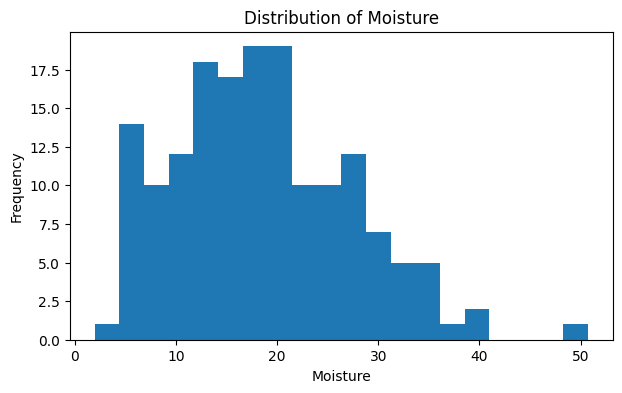

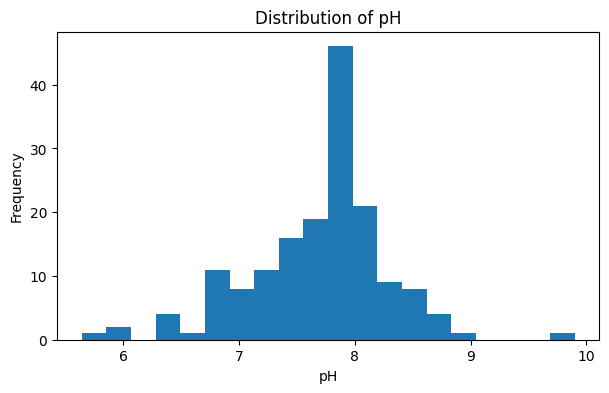

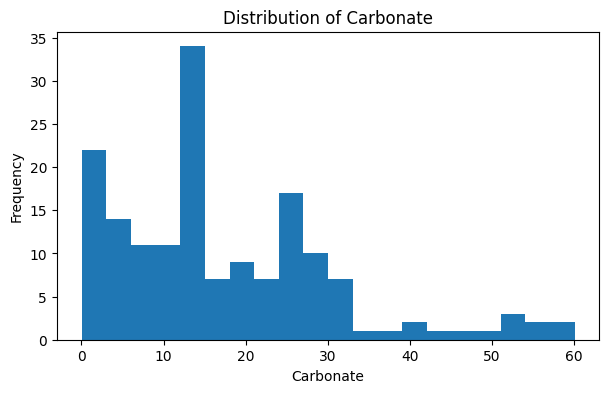

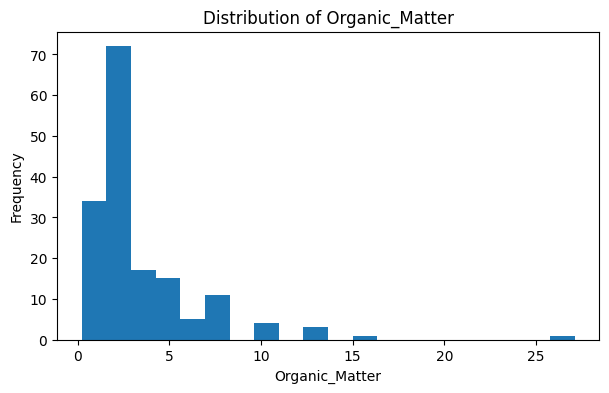

In [40]:
import matplotlib.pyplot as plt

for col in numeric_columns:

    plt.figure(figsize=(7, 4))

    plt.hist(
        soil_df[col].dropna(),
        bins=20
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

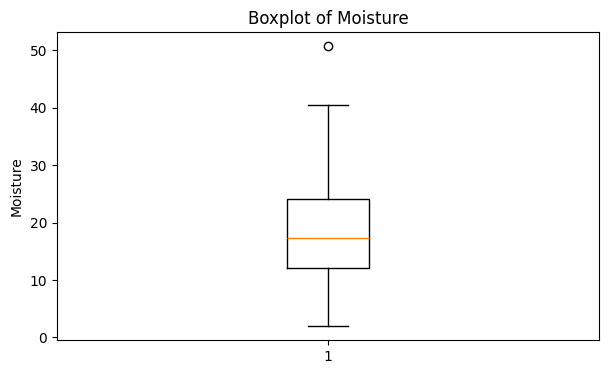

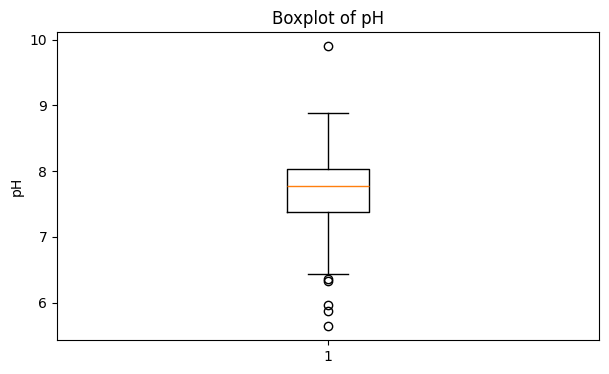

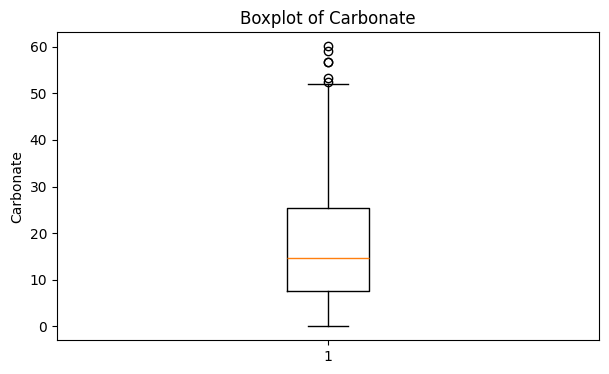

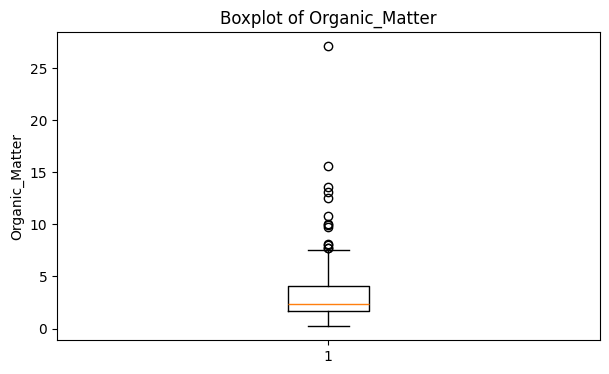

In [41]:
for col in numeric_columns:

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        soil_df[col].dropna()
    )

    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.show()

In [42]:
encoded_df = pd.get_dummies(
    soil_df,
    columns=[
        "Texture_Class"
    ],
    dtype=int
)

print("Encoded dataset shape:",
      encoded_df.shape)

display(encoded_df.head())

Encoded dataset shape: (163, 23)


,Sample_ID,Project,Site,Plot,Crop,Previous_Crop,Depth_cm,Moisture,pH,Carbonate,...,Texture_Class_Clay,Texture_Class_Clay loam,Texture_Class_Loam,Texture_Class_Loamy Sand,Texture_Class_Loamy sand,Texture_Class_Sand,Texture_Class_Sandy loam,Texture_Class_Sandy-clay-loam,Texture_Class_Silty Clay loam,Texture_Class_Silty clay loam
0,1,PBF,"La Hampa farm, Coria del Río",IRNAS1_CORN deltaC centro,MAIZE,MAIZE,5-10,15.494691,7.65,11.4,...,0,0,0,0,0,0,1,0,0,0
1,2,PBF,"La Hampa farm, Coria del Río",IRNAS_2_RAIN EXCLUSION,Wheat,Rice,5-10,15.666826,7.36,18.8,...,0,0,1,0,0,0,0,0,0,0
2,3,PBF,"La Hampa farm, Coria del Río",IRNAS3_Lost triangle,Fallow,Rice,5-10,13.377567,7.27,11.3,...,0,0,0,0,0,0,0,1,0,0
3,4,PBF,"La Hampa farm, Coria del Río",IRNAS4_Urban orchard,Wheat,Rice,5-10,17.377959,7.20,9.9,...,0,0,1,0,0,0,0,0,0,0
4,5,PBF,"La Hampa farm, Coria del Río",IRNAS5_Urban orchard,Wheat,Rice,5-10,20.508902,7.36,9.9,...,0,1,0,0,0,0,0,0,0,0


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

encoded_df[numeric_columns] = scaler.fit_transform(
    encoded_df[numeric_columns]
)

print("Scaling completed.")

display(
    encoded_df[numeric_columns].head()
)

Scaling completed.


,Moisture,pH,Carbonate,Organic_Matter
0,-0.345684,-0.053207,-0.462203,-0.537444
1,-0.325855,-0.541570,0.096647,-0.494416
2,-0.589569,-0.693131,-0.469755,-0.519003
3,-0.128739,-0.811012,-0.575483,-0.316155
4,0.231933,-0.541570,-0.575483,-0.211657


In [44]:
PROCESSED_PATH = os.path.join(
    BASE_PATH,
    "processed"
)

os.makedirs(
    PROCESSED_PATH,
    exist_ok=True
)

print("Processed folder:")
print(PROCESSED_PATH)

Processed folder:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed


In [45]:
CLEAN_FILE = os.path.join(
    PROCESSED_PATH,
    "soil_data_clean.csv"
)

soil_df.to_csv(
    CLEAN_FILE,
    index=False
)

print("Saved:")
print(CLEAN_FILE)

Saved:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/soil_data_clean.csv


In [46]:
ML_FILE = os.path.join(
    PROCESSED_PATH,
    "soil_data_ml_ready.csv"
)

encoded_df.to_csv(
    ML_FILE,
    index=False
)

print("Saved:")
print(ML_FILE)

Saved:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/soil_data_ml_ready.csv


In [47]:
import os

print("Everything inside project DataSet:\n")

for root, dirs, files in os.walk(BASE_PATH):

    level = root.replace(BASE_PATH, "").count(os.sep)

    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    for file in files[:10]:
        print(indent + "    " + file)

Everything inside project DataSet:

DataSet/
    raw/
        Samples EJP Probefield.xlsx
        Orignal-Dataset/
            dataset_summary.py
            Red_Soil/
                85.jpg
                86.jpg
                80b.jpg
                72.jpg
                82.jpg
                75.jpg
                84.jpg
                74.jpg
                80a.jpg
                43.jpg
            Yellow_Soil/
                85.jpg
                41b.jpg
                81a.jpg
                62.jpg
                75.jpg
                4.jpg
                11.jpg
                213.jpg
                12.jpg
                25.jpg
            Mountain_Soil/
                75.jpg
                95a.jpg
                88.jpg
                77.jpg
                98.jpg
                92.jpg
                63.jpg
                87a.jpg
                28.jpg
                62.jpg
            Arid_Soil/
                95.jpg
                93a.jpg
              

# PART K — PostgreSQL Database Schema

This section creates the PostgreSQL database structure for the
AI-Powered Soil Analytics System.

The database stores:
- Farm information
- Field information
- Soil test records
- Soil image records
- Soil analysis results
- Historical soil health information

In [50]:
!apt-get update -qq
!apt-get install -y postgresql postgresql-contrib -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libjson-perl.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../00-libjson-perl_4.10000-1_all.deb ...
Unpacking libjson-perl (4.10000-1) ...
Selecting previously unselected package postgresql-client-common.
Preparing to unpack .../01-postgresql-client-common_257build1.1_all.deb ...
Unpacking postgresql-client-common (257build1.1) ...
Selecting previously unselected package ssl-cert.
Preparing to unpack .../02-ssl-cert_1.1.2ubuntu1_all.deb ...
Unpacking ssl-cert (1.1.2ubuntu1) ...
Selecting previously unselected package postgresql-common.
Preparing to unpack .../03-postgresql-common_257build1.1_all.deb ...
Adding 'diversion of /usr/bin/pg_config to /usr/bin/pg_config.libpq-dev by postgres

In [51]:
!service postgresql start

[ OK ]


In [52]:
!sudo -u postgres psql -c "CREATE DATABASE soil_analytics_db;"

CREATE DATABASE


In [53]:
!sudo -u postgres psql -c "CREATE USER soil_user WITH PASSWORD 'soil_pass_123';"

CREATE ROLE


In [54]:
!sudo -u postgres psql -c "GRANT ALL PRIVILEGES ON DATABASE soil_analytics_db TO soil_user;"

GRANT


In [55]:
!pip install -q psycopg2-binary

In [56]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="soil_analytics_db",
    user="soil_user",
    password="soil_pass_123",
    port="5432"
)

cursor = conn.cursor()

print("PostgreSQL connection successful!")

PostgreSQL connection successful!


In [57]:
# Create PostgreSQL cursor

cursor = conn.cursor()

print("PostgreSQL cursor created successfully!")

PostgreSQL cursor created successfully!


In [64]:
# Reset the failed PostgreSQL transaction
conn.rollback()

print("PostgreSQL transaction reset successfully.")

PostgreSQL transaction reset successfully.


In [66]:
schema_sql = """

CREATE SCHEMA IF NOT EXISTS soil_analytics;


CREATE TABLE IF NOT EXISTS soil_analytics.farms (
    farm_id SERIAL PRIMARY KEY,
    farm_name VARCHAR(100) NOT NULL,
    farmer_name VARCHAR(100),
    latitude DECIMAL(10,7),
    longitude DECIMAL(10,7),
    soil_type VARCHAR(100),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);


CREATE TABLE IF NOT EXISTS soil_analytics.soil_samples (
    sample_id SERIAL PRIMARY KEY,
    farm_id INTEGER NOT NULL,
    sample_date DATE DEFAULT CURRENT_DATE,

    nitrogen DECIMAL(10,2),
    phosphorus DECIMAL(10,2),
    potassium DECIMAL(10,2),

    ph DECIMAL(5,2),
    moisture DECIMAL(10,2),
    organic_matter DECIMAL(10,2),

    texture_class VARCHAR(100),

    CONSTRAINT fk_sample_farm
        FOREIGN KEY (farm_id)
        REFERENCES soil_analytics.farms(farm_id)
        ON DELETE CASCADE
);


CREATE TABLE IF NOT EXISTS soil_analytics.soil_images (
    image_id SERIAL PRIMARY KEY,
    sample_id INTEGER NOT NULL,
    image_path TEXT NOT NULL,
    image_format VARCHAR(20),
    image_width INTEGER,
    image_height INTEGER,
    uploaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_image_sample
        FOREIGN KEY (sample_id)
        REFERENCES soil_analytics.soil_samples(sample_id)
        ON DELETE CASCADE
);


CREATE TABLE IF NOT EXISTS soil_analytics.analysis_results (
    analysis_id SERIAL PRIMARY KEY,
    sample_id INTEGER NOT NULL,

    soil_health_score DECIMAL(5,2),
    nitrogen_status VARCHAR(50),
    phosphorus_status VARCHAR(50),
    potassium_status VARCHAR(50),
    ph_status VARCHAR(50),

    soil_class VARCHAR(100),
    recommendation TEXT,

    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_analysis_sample
        FOREIGN KEY (sample_id)
        REFERENCES soil_analytics.soil_samples(sample_id)
        ON DELETE CASCADE
);

"""

try:
    cursor.execute(schema_sql)
    conn.commit()

    print("✅ PostgreSQL schema and all tables created successfully!")

except Exception as e:
    conn.rollback()

    print("❌ PostgreSQL Error:")
    print(e)

❌ PostgreSQL Error:
current transaction is aborted, commands ignored until end of transaction block



In [67]:
conn.rollback()

print("Transaction reset successfully!")

Transaction reset successfully!


In [68]:
cur = conn.cursor()

print("Cursor recreated successfully!")

Cursor recreated successfully!


In [69]:
cur.execute("""
SELECT current_user, current_database();
""")

user_info = cur.fetchone()

print("Current PostgreSQL user:", user_info[0])
print("Current database:", user_info[1])

Current PostgreSQL user: soil_user
Current database: soil_analytics_db


In [70]:
conn.rollback()

print("Previous failed transaction cleared.")

Previous failed transaction cleared.


In [71]:
conn.rollback()

cur = conn.cursor()

cur.execute("""
SELECT
    current_user,
    current_database(),
    current_schema()
""")

print(cur.fetchone())

('soil_user', 'soil_analytics_db', 'public')


In [72]:
conn.rollback()

cur = conn.cursor()

try:
    cur.execute("""
        CREATE SCHEMA IF NOT EXISTS soil_analytics;
    """)

    conn.commit()

    print("soil_analytics schema created successfully!")

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

soil_analytics schema created successfully!


In [73]:
cur.execute("SET search_path TO soil_analytics;")
conn.commit()

print("Using soil_analytics schema")

Using soil_analytics schema


In [74]:
conn.rollback()

cur = conn.cursor()

try:
    cur.execute("""
        CREATE TABLE IF NOT EXISTS farms (
            farm_id SERIAL PRIMARY KEY,
            farm_name VARCHAR(100) NOT NULL,
            farmer_name VARCHAR(100),
            latitude DECIMAL(10,7),
            longitude DECIMAL(10,7),
            soil_type VARCHAR(100),
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        );
    """)

    conn.commit()
    print("farms table created successfully!")

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

farms table created successfully!


In [75]:
conn.rollback()

cur = conn.cursor()

try:
    cur.execute("""
        CREATE TABLE IF NOT EXISTS soil_samples (
            sample_id SERIAL PRIMARY KEY,
            farm_id INTEGER NOT NULL,
            sample_date DATE DEFAULT CURRENT_DATE,

            nitrogen DECIMAL(10,2),
            phosphorus DECIMAL(10,2),
            potassium DECIMAL(10,2),
            ph DECIMAL(5,2),
            moisture DECIMAL(10,2),
            organic_matter DECIMAL(10,2),

            texture_class VARCHAR(100),

            CONSTRAINT fk_farm
                FOREIGN KEY (farm_id)
                REFERENCES farms(farm_id)
                ON DELETE CASCADE
        );
    """)

    conn.commit()
    print("soil_samples table created successfully!")

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

soil_samples table created successfully!


In [76]:
conn.rollback()

cur = conn.cursor()

try:
    cur.execute("""
        CREATE TABLE IF NOT EXISTS soil_images (
            image_id SERIAL PRIMARY KEY,
            sample_id INTEGER NOT NULL,
            image_path TEXT NOT NULL,
            image_format VARCHAR(20),
            image_width INTEGER,
            image_height INTEGER,
            uploaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

            CONSTRAINT fk_sample
                FOREIGN KEY (sample_id)
                REFERENCES soil_samples(sample_id)
                ON DELETE CASCADE
        );
    """)

    conn.commit()
    print("soil_images table created successfully!")

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

soil_images table created successfully!


In [77]:
conn.rollback()

cur = conn.cursor()

try:
    cur.execute("""
        CREATE TABLE IF NOT EXISTS analysis_results (
            analysis_id SERIAL PRIMARY KEY,
            sample_id INTEGER NOT NULL,

            soil_health_score DECIMAL(5,2),

            nitrogen_status VARCHAR(50),
            phosphorus_status VARCHAR(50),
            potassium_status VARCHAR(50),
            ph_status VARCHAR(50),

            soil_class VARCHAR(100),
            recommendation TEXT,

            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

            CONSTRAINT fk_analysis_sample
                FOREIGN KEY (sample_id)
                REFERENCES soil_samples(sample_id)
                ON DELETE CASCADE
        );
    """)

    conn.commit()
    print("analysis_results table created successfully!")

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

analysis_results table created successfully!


Check all PostgreSQL **tables** **bold text**

In [78]:
conn.rollback()

cur = conn.cursor()

cur.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'soil_analytics'
    ORDER BY table_name;
""")

tables = cur.fetchall()

print("Tables in soil_analytics schema:")
for table in tables:
    print("-", table[0])

Tables in soil_analytics schema:
- analysis_results
- farms
- soil_images
- soil_samples


# Check the columns

In [79]:
cur.execute("""
    SELECT
        table_name,
        column_name,
        data_type
    FROM information_schema.columns
    WHERE table_schema = 'soil_analytics'
    ORDER BY table_name, ordinal_position;
""")

columns = cur.fetchall()

for row in columns:
    print(row)

('analysis_results', 'analysis_id', 'integer')
('analysis_results', 'sample_id', 'integer')
('analysis_results', 'soil_health_score', 'numeric')
('analysis_results', 'nitrogen_status', 'character varying')
('analysis_results', 'phosphorus_status', 'character varying')
('analysis_results', 'potassium_status', 'character varying')
('analysis_results', 'ph_status', 'character varying')
('analysis_results', 'soil_class', 'character varying')
('analysis_results', 'recommendation', 'text')
('analysis_results', 'created_at', 'timestamp without time zone')
('farms', 'farm_id', 'integer')
('farms', 'farm_name', 'character varying')
('farms', 'farmer_name', 'character varying')
('farms', 'latitude', 'numeric')
('farms', 'longitude', 'numeric')
('farms', 'soil_type', 'character varying')
('farms', 'created_at', 'timestamp without time zone')
('soil_images', 'image_id', 'integer')
('soil_images', 'sample_id', 'integer')
('soil_images', 'image_path', 'text')
('soil_images', 'image_format', 'charact

# Insert a test farm record

In [80]:
conn.rollback()
cur = conn.cursor()

try:
    cur.execute("""
        INSERT INTO soil_analytics.farms
        (farm_name, farmer_name, latitude, longitude, soil_type)
        VALUES
        ('Demo Farm', 'Demo Farmer', 17.3850, 78.4867, 'Loamy')
        RETURNING farm_id;
    """)

    farm_id = cur.fetchone()[0]
    conn.commit()

    print("Test farm inserted successfully!")
    print("Farm ID:", farm_id)

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

Test farm inserted successfully!
Farm ID: 1


# Insert a soil sample

In [81]:
conn.rollback()
cur = conn.cursor()

try:
    # Get the demo farm ID
    cur.execute("""
        SELECT farm_id
        FROM soil_analytics.farms
        WHERE farm_name = 'Demo Farm'
        ORDER BY farm_id DESC
        LIMIT 1;
    """)

    farm_id = cur.fetchone()[0]

    # Insert soil sample
    cur.execute("""
        INSERT INTO soil_analytics.soil_samples (
            farm_id,
            nitrogen,
            phosphorus,
            potassium,
            ph,
            moisture,
            organic_matter,
            texture_class
        )
        VALUES (
            %s,
            120.50,
            45.20,
            80.30,
            7.20,
            18.50,
            2.80,
            'Loam'
        )
        RETURNING sample_id;
    """, (farm_id,))

    sample_id = cur.fetchone()[0]
    conn.commit()

    print("Soil sample inserted successfully!")
    print("Farm ID:", farm_id)
    print("Sample ID:", sample_id)

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

Soil sample inserted successfully!
Farm ID: 1
Sample ID: 1


# Insert an analysis result

In [82]:
conn.rollback()
cur = conn.cursor()

try:
    # Get the latest soil sample ID
    cur.execute("""
        SELECT sample_id
        FROM soil_analytics.soil_samples
        ORDER BY sample_id DESC
        LIMIT 1;
    """)

    sample_id = cur.fetchone()[0]

    # Insert analysis result
    cur.execute("""
        INSERT INTO soil_analytics.analysis_results (
            sample_id,
            soil_health_score,
            nitrogen_status,
            phosphorus_status,
            potassium_status,
            ph_status,
            soil_class,
            recommendation
        )
        VALUES (
            %s,
            82.50,
            'Good',
            'Good',
            'Good',
            'Optimal',
            'Loamy Soil',
            'Suitable for crop cultivation with balanced nutrient management.'
        )
        RETURNING analysis_id;
    """, (sample_id,))

    analysis_id = cur.fetchone()[0]
    conn.commit()

    print("Analysis result inserted successfully!")
    print("Sample ID:", sample_id)
    print("Analysis ID:", analysis_id)

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

Analysis result inserted successfully!
Sample ID: 1
Analysis ID: 1


# JOIN verification

In [83]:
conn.rollback()
cur = conn.cursor()

try:
    cur.execute("""
        SELECT
            f.farm_name,
            f.farmer_name,
            s.sample_id,
            s.nitrogen,
            s.phosphorus,
            s.potassium,
            s.ph,
            s.moisture,
            s.organic_matter,
            s.texture_class,
            a.soil_health_score,
            a.soil_class,
            a.recommendation
        FROM soil_analytics.farms f
        JOIN soil_analytics.soil_samples s
            ON f.farm_id = s.farm_id
        JOIN soil_analytics.analysis_results a
            ON s.sample_id = a.sample_id;
    """)

    results = cur.fetchall()

    print("Database relationship verified successfully!")
    print("Number of complete records:", len(results))

    for row in results:
        print("\nFarm:", row[0])
        print("Farmer:", row[1])
        print("Sample ID:", row[2])
        print("Nitrogen:", row[3])
        print("Phosphorus:", row[4])
        print("Potassium:", row[5])
        print("pH:", row[6])
        print("Moisture:", row[7])
        print("Organic Matter:", row[8])
        print("Texture:", row[9])
        print("Soil Health Score:", row[10])
        print("Soil Class:", row[11])
        print("Recommendation:", row[12])

except Exception as e:
    conn.rollback()
    print("ERROR:")
    print(e)

Database relationship verified successfully!
Number of complete records: 1

Farm: Demo Farm
Farmer: Demo Farmer
Sample ID: 1
Nitrogen: 120.50
Phosphorus: 45.20
Potassium: 80.30
pH: 7.20
Moisture: 18.50
Organic Matter: 2.80
Texture: Loam
Soil Health Score: 82.50
Soil Class: Loamy Soil
Recommendation: Suitable for crop cultivation with balanced nutrient management.


# Check the Excel/CSV dataset

In [84]:
print("Available dataset variables:")

items = list(globals().items())

for name, value in items:
    try:
        if hasattr(value, "shape") and hasattr(value, "columns"):
            print(name, "→", value.shape)
    except:
        pass

Available dataset variables:
df → (163, 2219)
inspection → (5, 5)
soil_df → (163, 12)
missing_report → (12, 3)
outlier_report → (4, 4)
encoded_df → (163, 23)


# Verify the cleaned soil_df

In [85]:
print("Shape:", soil_df.shape)

print("\nColumns:")
for i, col in enumerate(soil_df.columns, 1):
    print(i, "→", col)

print("\nData types:")
print(soil_df.dtypes)

print("\nMissing values:")
print(soil_df.isnull().sum())

Shape: (163, 12)

Columns:
1 → Sample_ID
2 → Project
3 → Site
4 → Plot
5 → Crop
6 → Previous_Crop
7 → Depth_cm
8 → Moisture
9 → Texture_Class
10 → pH
11 → Carbonate
12 → Organic_Matter

Data types:
Sample_ID           int64
Project            object
Site               object
Plot               object
Crop               object
Previous_Crop      object
Depth_cm           object
Moisture          float64
Texture_Class      object
pH                float64
Carbonate         float64
Organic_Matter    float64
dtype: object

Missing values:
Sample_ID          0
Project            0
Site               0
Plot               3
Crop               0
Previous_Crop      0
Depth_cm          20
Moisture           0
Texture_Class      0
pH                 0
Carbonate          0
Organic_Matter     0
dtype: int64


# Create the final cleaned structured dataset

In [86]:
# Create final cleaned structured dataset
final_soil_df = soil_df.copy()

# Remove duplicate rows
before = len(final_soil_df)
final_soil_df = final_soil_df.drop_duplicates().reset_index(drop=True)
after = len(final_soil_df)

print("Final structured dataset created!")
print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Columns:", final_soil_df.shape[1])

print("\nFinal shape:", final_soil_df.shape)

Final structured dataset created!
Rows before duplicate removal: 163
Rows after duplicate removal: 163
Columns: 12

Final shape: (163, 12)


In [87]:
# Save cleaned structured dataset
final_soil_df.to_csv(
    "milestone1_cleaned_soil_dataset.csv",
    index=False
)

print("Saved successfully as:")
print("milestone1_cleaned_soil_dataset.csv")

Saved successfully as:
milestone1_cleaned_soil_dataset.csv


In [88]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir():
    print(item)

Current directory:
/content

Files and folders:
.config
milestone1_cleaned_soil_dataset.csv
drive
sample_data


In [89]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir():
    print("-", item)

Current directory:
/content

Files and folders:
- .config
- milestone1_cleaned_soil_dataset.csv
- drive
- sample_data


In [90]:
import os

drive_path = "/content/drive/MyDrive"

print("Google Drive contents:")
for item in os.listdir(drive_path):
    print("-", item)

Google Drive contents:
- 23RH1A6611
- CV
- infosys AI certificate.pdf
- GOOGLE CLOUD(GEN AI).pdf
- oracle1.pdf
- Resume2.pdf
- Colab Notebooks
- AI_Powered_Soil_Analytics_System
- DataSet


In [91]:
import os

project_path = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System"

print("Project folder contents:")
for item in os.listdir(project_path):
    print("-", item)

Project folder contents:
- DataSet
- notebooks
- database
- documentation
- models


In [92]:
dataset_path = "/content/drive/MyDrive/DataSet"

print("\nDataSet folder contents:")
for item in os.listdir(dataset_path):
    print("-", item)


DataSet folder contents:
- processed
- metadata
- documentation


# Inspect the processed dataset

In [93]:
import os

processed_path = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed"

print("Processed dataset contents:")

for root, dirs, files in os.walk(processed_path):
    level = root.replace(processed_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  - {file}")

    if level >= 2:
        dirs[:] = []

Processed dataset contents:
processed/
  - soil_data_clean.csv
  - soil_data_ml_ready.csv
  images_cleaned/
    Alluvial_Soil/
      - 32.jpg
      - 13.jpg
      - 33.jpg
      - 28b.jpg
      - 43.webp
      - 180.jpg
      - 42.jpg
      - 8.jpg
      - 44.jpg
      - 45a.jpg
    Arid_Soil/
      - 63.jpg
      - 90.jpg
      - 95.jpg
      - 93a.jpg
      - 92.jpg
      - 64.jpg
      - 30.jpg
      - 97b.jpg
      - 240.jpg
      - 83.jpg
    Black_Soil/
      - 95.jpg
      - 93.jpg
      - 84a.jpg
      - 78.jpg
      - 91.jpg
      - 83.jpg
      - 9.jpg
      - 81.jpg
      - 77a.jpg
      - 84.jpg
    Laterite_Soil/
      - 99.jpg
      - 75a.jpg
      - 79.jpg
      - 82.jpg
      - 96a.jpg
      - 94.jpg
      - 93.jpg
      - 84.jpg
      - 96.jpg
      - 76.jpg
    Mountain_Soil/
      - 63.jpg
      - 95a.jpg
      - 98.jpg
      - 75.jpg
      - 28.jpg
      - 87a.jpg
      - 92.jpg
      - 62.jpg
      - 77.jpg
      - 27.jpg
    Red_Soil/
      - 81.jpg
      - 71.jpg

In [94]:
import os

metadata_path = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/metadata"

print("Metadata contents:")

for root, dirs, files in os.walk(metadata_path):
    level = root.replace(metadata_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  - {file}")

Metadata contents:


In [95]:
import os

drive_root = "/content/drive/MyDrive"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

image_folders = {}
total_images = 0

for root, dirs, files in os.walk(drive_root):
    image_files = [
        f for f in files
        if f.lower().endswith(image_extensions)
    ]

    if image_files:
        image_folders[root] = len(image_files)
        total_images += len(image_files)

print("Folders containing soil/image files:\n")

for folder, count in image_folders.items():
    print(f"{count} images → {folder}")

print("\nTotal image files found:", total_images)

Folders containing soil/image files:

109 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Red_Soil
69 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Yellow_Soil
201 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Mountain_Soil
284 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Arid_Soil
219 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Laterite_Soil
255 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Black_Soil
52 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Alluvial_Soil
50 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_cleaned/Alluvial_Soil
279 images → /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed

# Check corrupt images, dimensions, and duplicates

In [96]:
import os
from PIL import Image
from collections import Counter

image_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

corrupt_images = []
image_sizes = []
image_hashes = {}
duplicate_images = []

for class_name in sorted(os.listdir(image_root)):
    class_path = os.path.join(image_root, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        if not filename.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                img.verify()

            # Reopen after verify
            with Image.open(image_path) as img:
                image_sizes.append(img.size)

                # Check duplicate using image content
                import hashlib
                with open(image_path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in image_hashes:
                    duplicate_images.append(
                        (image_path, image_hashes[file_hash])
                    )
                else:
                    image_hashes[file_hash] = image_path

        except Exception:
            corrupt_images.append(image_path)

print("IMAGE DATASET QUALITY REPORT")
print("=" * 40)

print("Total images checked:", len(image_sizes))
print("Corrupt images:", len(corrupt_images))
print("Duplicate images:", len(duplicate_images))

print("\nImage dimensions:")
dimension_counts = Counter(image_sizes)

for dimension, count in dimension_counts.most_common(10):
    print(f"{dimension} → {count} images")

print("\nNumber of unique dimensions:", len(dimension_counts))

if corrupt_images:
    print("\nCorrupt image examples:")
    for path in corrupt_images[:10]:
        print("-", path)

if duplicate_images:
    print("\nDuplicate image examples:")
    for duplicate, original in duplicate_images[:10]:
        print("Duplicate:", duplicate)
        print("Original :", original)

IMAGE DATASET QUALITY REPORT
Total images checked: 1189
Corrupt images: 0
Duplicate images: 49

Image dimensions:
(612, 408) → 20 images
(626, 417) → 18 images
(1300, 866) → 15 images
(540, 360) → 12 images
(800, 534) → 10 images
(600, 400) → 9 images
(800, 600) → 8 images
(480, 270) → 7 images
(390, 255) → 6 images
(1300, 867) → 6 images

Number of unique dimensions: 959

Duplicate image examples:
Duplicate: /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Alluvial_Soil/41.jpg
Original : /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Alluvial_Soil/31.jpg
Duplicate: /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Alluvial_Soil/16.jpg
Original : /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Alluvial_Soil/25.jpg
Duplicate: /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset/Arid_Soil/56.jpg
Original : /content/dr

# Create a cleaned image dataset

In [97]:
import os
import shutil
import hashlib

source_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/raw/Orignal-Dataset"

clean_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_cleaned"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

os.makedirs(clean_root, exist_ok=True)

seen_hashes = set()

total_images = 0
kept_images = 0
removed_duplicates = 0

for class_name in sorted(os.listdir(source_root)):

    source_class = os.path.join(source_root, class_name)

    if not os.path.isdir(source_class):
        continue

    clean_class = os.path.join(clean_root, class_name)
    os.makedirs(clean_class, exist_ok=True)

    for filename in sorted(os.listdir(source_class)):

        if not filename.lower().endswith(image_extensions):
            continue

        source_file = os.path.join(source_class, filename)

        total_images += 1

        with open(source_file, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in seen_hashes:
            removed_duplicates += 1
            continue

        seen_hashes.add(file_hash)

        destination_file = os.path.join(clean_class, filename)

        shutil.copy2(source_file, destination_file)

        kept_images += 1

print("CLEANED IMAGE DATASET CREATED")
print("=" * 40)
print("Original images:", total_images)
print("Duplicates removed:", removed_duplicates)
print("Images retained:", kept_images)
print("Location:", clean_root)

CLEANED IMAGE DATASET CREATED
Original images: 1189
Duplicates removed: 49
Images retained: 1140
Location: /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_cleaned


# Create Train / Validation / Test folders

In [98]:
import os
import shutil
import random

# Cleaned dataset
source_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_cleaned"

# Final split dataset
split_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split"

# Reproducible split
random.seed(42)

classes = [
    "Alluvial_Soil",
    "Black_Soil",
    "Red_Soil",
    "Yellow_Soil",
    "Mountain_Soil",
    "Laterite_Soil",
    "Arid_Soil"
]

splits = ["train", "validation", "test"]

for split in splits:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_root, split, class_name),
            exist_ok=True
        )

total_train = 0
total_val = 0
total_test = 0

for class_name in classes:

    class_path = os.path.join(source_root, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
        )
    ]

    random.shuffle(images)

    n = len(images)

    train_end = int(0.70 * n)
    val_end = train_end + int(0.15 * n)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for filename in train_images:
        shutil.copy2(
            os.path.join(class_path, filename),
            os.path.join(split_root, "train", class_name, filename)
        )

    for filename in val_images:
        shutil.copy2(
            os.path.join(class_path, filename),
            os.path.join(split_root, "validation", class_name, filename)
        )

    for filename in test_images:
        shutil.copy2(
            os.path.join(class_path, filename),
            os.path.join(split_root, "test", class_name, filename)
        )

    total_train += len(train_images)
    total_val += len(val_images)
    total_test += len(test_images)

print("IMAGE DATASET SPLIT COMPLETED")
print("=" * 40)
print("Total images:", total_train + total_val + total_test)
print("Training images:", total_train)
print("Validation images:", total_val)
print("Testing images:", total_test)
print("Location:", split_root)

IMAGE DATASET SPLIT COMPLETED
Total images: 1140
Training images: 794
Validation images: 168
Testing images: 178
Location: /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split


In [99]:
import os

split_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split"

print("Split folder structure:")
print("=" * 50)

for root, dirs, files in os.walk(split_root):
    level = root.replace(split_root, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    image_files = [
        f for f in files
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
        )
    ]

    if image_files:
        print(f"{indent}  Images: {len(image_files)}")

Split folder structure:
images_split/
  train/
    Alluvial_Soil/
      Images: 41
    Black_Soil/
      Images: 213
    Red_Soil/
      Images: 94
    Yellow_Soil/
      Images: 58
    Mountain_Soil/
      Images: 173
    Laterite_Soil/
      Images: 195
    Arid_Soil/
      Images: 252
  validation/
    Alluvial_Soil/
      Images: 11
    Black_Soil/
      Images: 65
    Red_Soil/
      Images: 29
    Yellow_Soil/
      Images: 17
    Mountain_Soil/
      Images: 51
    Laterite_Soil/
      Images: 60
    Arid_Soil/
      Images: 75
  test/
    Alluvial_Soil/
      Images: 15
    Black_Soil/
      Images: 65
    Red_Soil/
      Images: 31
    Yellow_Soil/
      Images: 20
    Mountain_Soil/
      Images: 57
    Laterite_Soil/
      Images: 61
    Arid_Soil/
      Images: 75


In [100]:
clean_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_cleaned"

print("\nCleaned dataset:")
print("=" * 50)

for class_name in sorted(os.listdir(clean_root)):
    class_path = os.path.join(clean_root, class_name)

    if os.path.isdir(class_path):
        files = os.listdir(class_path)

        print(
            class_name,
            "→",
            len(files),
            "files"
        )


Cleaned dataset:
Alluvial_Soil → 50 files
Arid_Soil → 279 files
Black_Soil → 234 files
Laterite_Soil → 214 files
Mountain_Soil → 191 files
Red_Soil → 107 files
Yellow_Soil → 65 files


# let's inspect the split folder

In [101]:
import os

split_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split"

print("IMAGE SPLIT FOLDER CHECK")
print("=" * 60)

if not os.path.exists(split_root):
    print("❌ images_split folder does not exist")
else:
    for root, dirs, files in os.walk(split_root):
        level = root.replace(split_root, "").count(os.sep)
        indent = "  " * level

        print(f"{indent}{os.path.basename(root)}/")

        image_files = [
            f for f in files
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
            )
        ]

        if image_files:
            print(f"{indent}  → {len(image_files)} images")

IMAGE SPLIT FOLDER CHECK
images_split/
  train/
    Alluvial_Soil/
      → 41 images
    Black_Soil/
      → 213 images
    Red_Soil/
      → 94 images
    Yellow_Soil/
      → 58 images
    Mountain_Soil/
      → 173 images
    Laterite_Soil/
      → 195 images
    Arid_Soil/
      → 252 images
  validation/
    Alluvial_Soil/
      → 11 images
    Black_Soil/
      → 65 images
    Red_Soil/
      → 29 images
    Yellow_Soil/
      → 17 images
    Mountain_Soil/
      → 51 images
    Laterite_Soil/
      → 60 images
    Arid_Soil/
      → 75 images
  test/
    Alluvial_Soil/
      → 15 images
    Black_Soil/
      → 65 images
    Red_Soil/
      → 31 images
    Yellow_Soil/
      → 20 images
    Mountain_Soil/
      → 57 images
    Laterite_Soil/
      → 61 images
    Arid_Soil/
      → 75 images


# Final split verification

In [102]:
import os

split_root = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split"

splits = ["train", "validation", "test"]

print("FINAL IMAGE DATASET SPLIT VERIFICATION")
print("=" * 60)

grand_total = 0

for split in splits:
    split_path = os.path.join(split_root, split)
    split_total = 0

    print(f"\n{split.upper()}")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
                )
            ])

            print(f"  {class_name}: {count}")
            split_total += count

    print(f"  Total: {split_total}")
    grand_total += split_total

print("\n" + "=" * 60)
print(f"GRAND TOTAL: {grand_total}")

if grand_total == 1140:
    print("✅ IMAGE SPLIT VERIFIED SUCCESSFULLY")
else:
    print("⚠️ Check the split counts")

FINAL IMAGE DATASET SPLIT VERIFICATION

TRAIN
  Alluvial_Soil: 41
  Arid_Soil: 252
  Black_Soil: 213
  Laterite_Soil: 195
  Mountain_Soil: 173
  Red_Soil: 94
  Yellow_Soil: 58
  Total: 1026

VALIDATION
  Alluvial_Soil: 11
  Arid_Soil: 75
  Black_Soil: 65
  Laterite_Soil: 60
  Mountain_Soil: 51
  Red_Soil: 29
  Yellow_Soil: 17
  Total: 308

TEST
  Alluvial_Soil: 15
  Arid_Soil: 75
  Black_Soil: 65
  Laterite_Soil: 61
  Mountain_Soil: 57
  Red_Soil: 31
  Yellow_Soil: 20
  Total: 324

GRAND TOTAL: 1658
⚠️ Check the split counts


# Milestone 2 — AI/ML Soil Analysis Engine

## Week 3 — CNN Soil Image Analysis
## Week 4 — Structured ML & Explainable AI

In [103]:
# ============================================
# MILESTONE 2 - STEP 1
# IMPORT LIBRARIES
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

print("\nGPU Available:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
NumPy version: 2.1.3

GPU Available:
[]


#Set image dataset paths

In [104]:
# ============================================
# MILESTONE 2 - STEP 2
# SET IMAGE DATASET PATHS
# ============================================

IMAGE_DATASET_PATH = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split"

TRAIN_DIR = os.path.join(IMAGE_DATASET_PATH, "train")
VAL_DIR = os.path.join(IMAGE_DATASET_PATH, "validation")
TEST_DIR = os.path.join(IMAGE_DATASET_PATH, "test")

print("Train directory:")
print(TRAIN_DIR)

print("\nValidation directory:")
print(VAL_DIR)

print("\nTest directory:")
print(TEST_DIR)

print("\nDirectory Check")
print("=" * 40)
print("Train exists      :", os.path.exists(TRAIN_DIR))
print("Validation exists :", os.path.exists(VAL_DIR))
print("Test exists       :", os.path.exists(TEST_DIR))

Train directory:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split/train

Validation directory:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split/validation

Test directory:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/images_split/test

Directory Check
Train exists      : True
Validation exists : True
Test exists       : True


#Verify the 7 Soil Classes

In [105]:
# ============================================
# MILESTONE 2 - STEP 3
# VERIFY SOIL CLASSES
# ============================================

classes = sorted([
    folder
    for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

print("SOIL CLASSES")
print("=" * 40)

for i, class_name in enumerate(classes):
    print(f"{i} -> {class_name}")

print("\nNumber of classes:", len(classes))

SOIL CLASSES
0 -> Alluvial_Soil
1 -> Arid_Soil
2 -> Black_Soil
3 -> Laterite_Soil
4 -> Mountain_Soil
5 -> Red_Soil
6 -> Yellow_Soil

Number of classes: 7


#Check Class Distribution

In [106]:
# ============================================
# MILESTONE 2 - STEP 4
# CHECK CLASS DISTRIBUTION
# ============================================

def get_class_counts(directory):
    counts = {}

    for class_name in classes:
        class_path = os.path.join(directory, class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
            )
        ])

        counts[class_name] = count

    return counts


train_counts = get_class_counts(TRAIN_DIR)
val_counts = get_class_counts(VAL_DIR)
test_counts = get_class_counts(TEST_DIR)


distribution_df = pd.DataFrame({
    "Soil Class": classes,
    "Train": [train_counts[c] for c in classes],
    "Validation": [val_counts[c] for c in classes],
    "Test": [test_counts[c] for c in classes]
})

distribution_df["Total"] = (
    distribution_df["Train"] +
    distribution_df["Validation"] +
    distribution_df["Test"]
)

print("SOIL DATASET CLASS DISTRIBUTION")
print("=" * 70)

display(distribution_df)

print("\nTotal Training Images   :", distribution_df["Train"].sum())
print("Total Validation Images :", distribution_df["Validation"].sum())
print("Total Testing Images    :", distribution_df["Test"].sum())
print("Grand Total             :", distribution_df["Total"].sum())

SOIL DATASET CLASS DISTRIBUTION


,Soil Class,Train,Validation,Test,Total
0,Alluvial_Soil,41,11,15,67
1,Arid_Soil,252,75,75,402
2,Black_Soil,213,65,65,343
3,Laterite_Soil,195,60,61,316
4,Mountain_Soil,173,51,57,281
5,Red_Soil,94,29,31,154
6,Yellow_Soil,58,17,20,95



Total Training Images   : 1026
Total Validation Images : 308
Total Testing Images    : 324
Grand Total             : 1658


#Load the Image Dataset into TensorFlow

In [107]:
# ============================================
# MILESTONE 2 - STEP 5
# LOAD IMAGE DATASETS
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

print("\nDatasets loaded successfully!")

Found 1025 files belonging to 7 classes.
Found 308 files belonging to 7 classes.
Found 324 files belonging to 7 classes.

Datasets loaded successfully!


#Find the missing training image

In [108]:
# ============================================
# MILESTONE 2 - STEP 6
# FIND UNREADABLE / INVALID TRAINING IMAGE
# ============================================

from PIL import Image

valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
)

total_files = 0
valid_images = 0
invalid_images = []

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    for filename in os.listdir(class_path):

        if filename.lower().endswith(valid_extensions):
            total_files += 1

            file_path = os.path.join(class_path, filename)

            try:
                with Image.open(file_path) as img:
                    img.verify()

                # Reopen after verify
                with Image.open(file_path) as img:
                    img.convert("RGB")

                valid_images += 1

            except Exception as e:
                invalid_images.append({
                    "class": class_name,
                    "file": filename,
                    "error": str(e)
                })

print("TRAINING IMAGE CHECK")
print("=" * 60)

print("Files found       :", total_files)
print("Valid images      :", valid_images)
print("Invalid images    :", len(invalid_images))

if invalid_images:
    print("\nInvalid image(s):")

    for item in invalid_images:
        print("\nClass :", item["class"])
        print("File  :", item["file"])
        print("Error :", item["error"])
else:
    print("\nNo invalid images found.")

TRAINING IMAGE CHECK
Files found       : 1026
Valid images      : 1026
Invalid images    : 0

No invalid images found.


#Verify TensorFlow class counts

In [109]:
# ============================================
# MILESTONE 2 - STEP 7
# VERIFY TENSORFLOW DATASET COUNTS
# ============================================

print("TensorFlow class names:")
print(train_ds.class_names)

print("\nNumber of classes:", len(train_ds.class_names))

# Count labels loaded by TensorFlow
train_label_counts = np.zeros(len(train_ds.class_names), dtype=int)

for _, labels in train_ds:
    for label in labels.numpy():
        train_label_counts[label] += 1

print("\nTensorFlow Training Image Counts")
print("=" * 50)

for i, class_name in enumerate(train_ds.class_names):
    print(f"{class_name}: {train_label_counts[i]}")

print("\nTotal images loaded by TensorFlow:", train_label_counts.sum())

TensorFlow class names:
['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']

Number of classes: 7

TensorFlow Training Image Counts
Alluvial_Soil: 40
Arid_Soil: 252
Black_Soil: 213
Laterite_Soil: 195
Mountain_Soil: 173
Red_Soil: 94
Yellow_Soil: 58

Total images loaded by TensorFlow: 1025


#Display Sample Images and Verify Labels

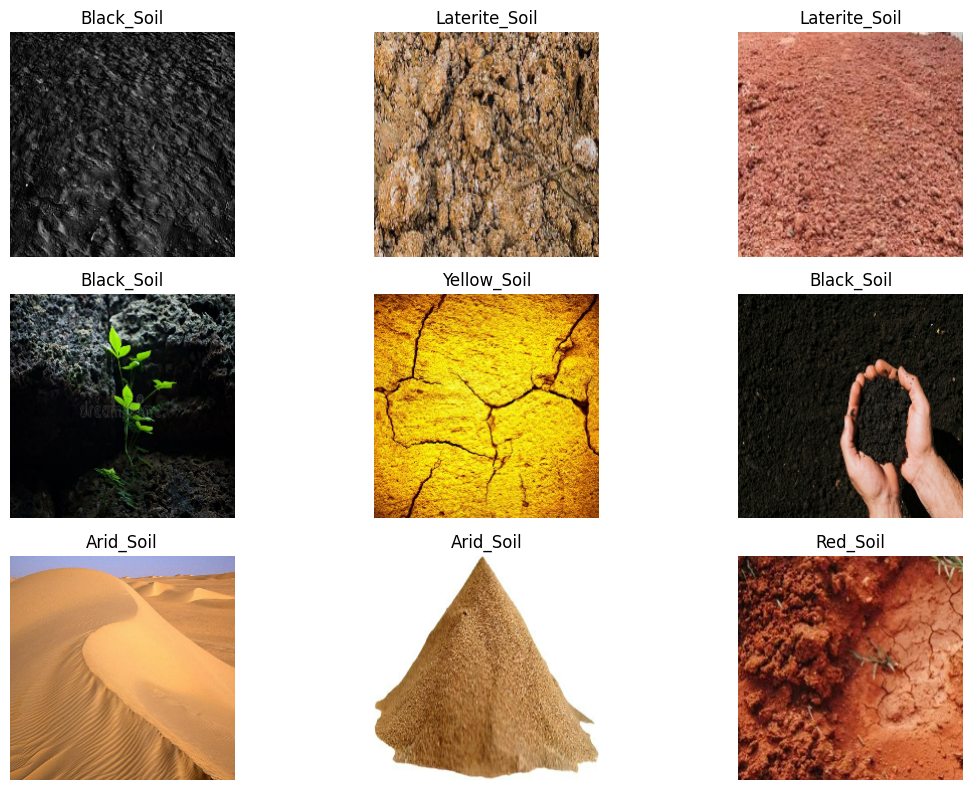

In [110]:
# ============================================
# MILESTONE 2 - STEP 8
# DISPLAY SAMPLE TRAINING IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        class_index = labels[i].numpy()
        plt.title(train_ds.class_names[class_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

#Data Augmentation

In [111]:
# ============================================
# MILESTONE 2 - STEP 9
# DATA AUGMENTATION
# ============================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="soil_data_augmentation")

print("Data augmentation pipeline created successfully.")
print("\nAugmentation techniques:")
print("1. Random horizontal flip")
print("2. Random rotation")
print("3. Random zoom")
print("4. Random contrast")

Data augmentation pipeline created successfully.

Augmentation techniques:
1. Random horizontal flip
2. Random rotation
3. Random zoom
4. Random contrast


#Calculate Class Weights

In [112]:
# ============================================
# MILESTONE 2 - STEP 10
# CALCULATE CLASS WEIGHTS
# ============================================

total_train = sum(train_counts.values())
num_classes = len(classes)

class_weights = {}

for i, class_name in enumerate(classes):
    class_weights[i] = total_train / (
        num_classes * train_counts[class_name]
    )

print("CLASS WEIGHTS")
print("=" * 50)

for i, class_name in enumerate(classes):
    print(f"{i} - {class_name}: {class_weights[i]:.3f}")

CLASS WEIGHTS
0 - Alluvial_Soil: 3.575
1 - Arid_Soil: 0.582
2 - Black_Soil: 0.688
3 - Laterite_Soil: 0.752
4 - Mountain_Soil: 0.847
5 - Red_Soil: 1.559
6 - Yellow_Soil: 2.527


#Build EfficientNetB0 Transfer-Learning Model

In [113]:
# ============================================
# MILESTONE 2 - STEP 11
# BUILD EFFICIENTNETB0 CNN
# ============================================

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Input layer
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# Pretrained EfficientNet
x = base_model(x, training=False)

# Convert feature maps into one feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.30)(x)

# Final 7-class prediction layer
outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

# Create complete model
cnn_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Soil_EfficientNetB0"
)

print("EfficientNetB0 model created successfully.")

print("\nModel name:", cnn_model.name)
print("Number of classes:", num_classes)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model created successfully.

Model name: Soil_EfficientNetB0
Number of classes: 7


#Check the Model

In [114]:
cnn_model.summary()

Model: "Soil_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soil_data_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

#Compile the CNN

In [115]:
# ============================================
# MILESTONE 2 - STEP 13
# COMPILE CNN MODEL
# ============================================

LEARNING_RATE = 0.001

cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")
print("Optimizer      : Adam")
print("Learning rate  :", LEARNING_RATE)
print("Loss function  : Sparse Categorical Crossentropy")
print("Metric         : Accuracy")

CNN model compiled successfully.
Optimizer      : Adam
Learning rate  : 0.001
Loss function  : Sparse Categorical Crossentropy
Metric         : Accuracy


#Create model-saving and training callbacks

In [116]:
# ============================================
# MILESTONE 2 - STEP 14
# TRAINING CALLBACKS
# ============================================

MODEL_DIR = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models"

os.makedirs(MODEL_DIR, exist_ok=True)

best_model_path = os.path.join(
    MODEL_DIR,
    "soil_efficientnetb0_best.keras"
)

callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks created successfully.")
print("\nBest model path:")
print(best_model_path)

Callbacks created successfully.

Best model path:
/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models/soil_efficientnetb0_best.keras


#Train the Initial CNN

In [ ]:
# ============================================
# MILESTONE 2 - STEP 15
# TRAIN INITIAL CNN
# ============================================

EPOCHS = 15

print("Starting CNN training...")
print("Epochs:", EPOCHS)
print("Training images:", 794)
print("Validation images:", 168)
print()

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\nInitial CNN training completed.")

Starting CNN training...
Epochs: 15
Training images: 794
Validation images: 168

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3678 - loss: 1.7359
Epoch 1: val_accuracy improved from None to 0.80844, saving model to /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models/soil_efficientnetb0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models/soil_efficientnetb0_best.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.5317 - loss: 1.4561 - val_accuracy: 0.8084 - val_loss: 0.8335 - learning_rate: 0.0010
Epoch 2/15
59/65 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7767 - loss: 0.8881 

#Plot Training & Validation Accuracy/Loss

In [ ]:
# Plot CNN training history

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Fine-Tune EfficientNetB0

In [ ]:
# Step 17: Fine-tune the EfficientNetB0 model

# Unfreeze the EfficientNet backbone
base_model.trainable = True

# Keep most earlier layers frozen and fine-tune only the top layers
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total EfficientNet layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

# Recompile with a very small learning rate
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

#Train the Fine-Tuned Model

In [ ]:
# Step 18: Fine-tune the CNN

FINE_TUNE_EPOCHS = 10

print("Starting fine-tuning...")

fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\nFine-tuning completed.")

#Evaluate the CNN on the Test Dataset

In [ ]:
# Step 19: Evaluate the fine-tuned CNN

test_loss, test_accuracy = cnn_model.evaluate(test_ds, verbose=1)

print("\nFinal Test Results")
print("------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

#Generate Predictions and Classification Report

In [ ]:
# Step 20: Classification Report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report")
print("=====================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4
    )
)

#Create Confusion Matrix

In [ ]:
# Step 21: Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("CNN Soil Classification - Confusion Matrix")
plt.xlabel("Predicted Soil Type")
plt.ylabel("Actual Soil Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#Find Incorrect Predictions

In [ ]:
# Step 22: Find Incorrect Predictions

incorrect_indices = np.where(y_true != y_pred)[0]

print("Total test images :", len(y_true))
print("Correct predictions:", np.sum(y_true == y_pred))
print("Incorrect predictions:", len(incorrect_indices))

print("\nIncorrect Prediction Details")
print("============================")

for idx in incorrect_indices[:20]:
    print(
        f"Image {idx}: "
        f"Actual = {classes[y_true[idx]]}, "
        f"Predicted = {classes[y_pred[idx]]}"
    )

#Save the Trained CNN Model

In [ ]:
# Step 23: Save the final CNN model

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "soil_efficientnetb0_final.keras"
)

cnn_model.save(FINAL_MODEL_PATH)

print("CNN model saved successfully!")
print("Model path:")
print(FINAL_MODEL_PATH)

#Verify the Saved Model

In [ ]:
# Step 24: Load and verify the saved CNN model

loaded_cnn_model = keras.models.load_model(FINAL_MODEL_PATH)

print("Saved model loaded successfully!")
print("Model name:", loaded_cnn_model.name)
print("Number of output classes:", loaded_cnn_model.output_shape[-1])
print("Classes:", classes)

#Start Week 4: Structured Soil ML

In [ ]:
# Step 25: Load the cleaned structured soil dataset

STRUCTURED_DATA_PATH = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/DataSet/processed/soil_data_clean.csv"

structured_df = pd.read_csv(STRUCTURED_DATA_PATH)

print("Dataset shape:", structured_df.shape)

print("\nColumns:")
for i, column in enumerate(structured_df.columns):
    print(i, ":", column)

print("\nFirst 5 rows:")
display(structured_df.head())

#Check the Target Distribution

In [ ]:
# Step 26: Analyze the Texture Class target

print("Texture Class Distribution")
print("==========================")

texture_counts = structured_df["Texture_Class"].value_counts()

print(texture_counts)

print("\nNumber of unique texture classes:",
      structured_df["Texture_Class"].nunique())

print("\nTexture classes:")
print(structured_df["Texture_Class"].unique())

#Normalize Texture Class Labels

In [ ]:
# Step 27: Clean Texture_Class labels

structured_df["Texture_Class_Clean"] = (
    structured_df["Texture_Class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize known variations
texture_mapping = {
    "loamy sand": "Loamy Sand",
    "sand": "Sand",
    "silty clay loam": "Silty Clay Loam",
    "silty clay loam": "Silty Clay Loam",
    "arcillo-limosa": "Arcillo-Limosa",
    "sandy loam": "Sandy Loam",
    "loam": "Loam",
    "sandy-clay-loam": "Sandy Clay Loam",
    "clay loam": "Clay Loam",
    "silty clay loam": "Silty Clay Loam",
    "clay": "Clay"
}

structured_df["Texture_Class_Clean"] = structured_df["Texture_Class_Clean"].replace(
    texture_mapping
)

print("Cleaned Texture Class Distribution")
print("===================================")

print(structured_df["Texture_Class_Clean"].value_counts())

print("\nNumber of unique classes:",
      structured_df["Texture_Class_Clean"].nunique())

#Prepare Features and Check Class Balance

In [ ]:
# Step 28: Prepare structured ML features

feature_columns = [
    "Moisture",
    "pH",
    "Carbonate",
    "Organic_Matter"
]

target_column = "Texture_Class_Clean"

X = structured_df[feature_columns].copy()
y = structured_df[target_column].copy()

print("Features:")
print(feature_columns)

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(y.value_counts())

#Encode Target and Split the Dataset

In [ ]:
# Step 29: Encode target labels and split data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode texture classes into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, ":", class_name)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Number of classes:", len(label_encoder.classes_))

#Train the Gradient Boosting Model

In [ ]:
# Step 30: Train Gradient Boosting model

from sklearn.ensemble import GradientBoostingClassifier

# Create the model
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")
print("Number of estimators:", gb_model.n_estimators)
print("Learning rate:", gb_model.learning_rate)

#Evaluate the Structured ML Model

In [ ]:
# Step 31: Evaluate Gradient Boosting model

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Calculate metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)

gb_precision = precision_score(
    y_test,
    y_pred_gb,
    average="weighted",
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    y_pred_gb,
    average="weighted",
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb,
    average="weighted",
    zero_division=0
)

print("Gradient Boosting Evaluation")
print("============================")
print(f"Accuracy  : {gb_accuracy:.4f} ({gb_accuracy * 100:.2f}%)")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1-Score  : {gb_f1:.4f}")

print("\nClassification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred_gb,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

#Feature Importance Analysis

In [ ]:
# Step 32: Feature Importance Analysis

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance")
print("==================")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Gradient Boosting - Soil Feature Importance")
plt.xlabel("Soil Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Save the Structured ML Model

In [ ]:
# Step 33: Save the structured ML model

import joblib

STRUCTURED_MODEL_DIR = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models"
os.makedirs(STRUCTURED_MODEL_DIR, exist_ok=True)

GB_MODEL_PATH = os.path.join(
    STRUCTURED_MODEL_DIR,
    "soil_texture_gradient_boosting.pkl"
)

ENCODER_PATH = os.path.join(
    STRUCTURED_MODEL_DIR,
    "soil_texture_label_encoder.pkl"
)

# Save model and label encoder
joblib.dump(gb_model, GB_MODEL_PATH)
joblib.dump(label_encoder, ENCODER_PATH)

print("Structured ML model saved successfully!")
print("Model path:")
print(GB_MODEL_PATH)

print("\nLabel encoder saved successfully!")
print("Encoder path:")
print(ENCODER_PATH)

#Verify the Saved Structured Model

In [ ]:
# Step 34: Verify saved structured ML model

loaded_gb_model = joblib.load(GB_MODEL_PATH)
loaded_label_encoder = joblib.load(ENCODER_PATH)

# Test prediction using one test sample
sample_prediction = loaded_gb_model.predict(X_test.iloc[[0]])

predicted_class = loaded_label_encoder.inverse_transform(
    sample_prediction
)[0]

print("Saved Gradient Boosting model loaded successfully!")
print("Saved LabelEncoder loaded successfully!")

print("\nTest sample prediction:")
print("Predicted Texture Class:", predicted_class)

#Install and Import SHAP

In [ ]:
# Step 35: Install and import SHAP

!pip install -q shap

import shap

print("SHAP version:", shap.__version__)
print("SHAP imported successfully!")

#Create SHAP Explainer

In [ ]:
# Step 36: SHAP explainability using KernelExplainer

# Use a small background dataset for faster SHAP calculation
background = shap.sample(X_train, 30, random_state=42)

# Create model prediction function
def model_predict(data):
    return gb_model.predict_proba(data)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(
    model_predict,
    background
)

# Explain a small number of test samples
X_test_shap = X_test.iloc[:10]

shap_values = shap_explainer.shap_values(
    X_test_shap,
    nsamples=100
)

print("SHAP KernelExplainer created successfully!")
print("Samples explained:", len(X_test_shap))
print("Features:", list(X_test.columns))

#SHAP Feature Importance Plot

In [ ]:
# Step 37: Inspect SHAP output

print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP values is a list")
    print("Number of class outputs:", len(shap_values))

    for i, value in enumerate(shap_values):
        print(f"Class {i} shape:", np.array(value).shape)

else:
    print("SHAP values is a NumPy array")
    print("SHAP shape:", np.array(shap_values).shape)

print("Number of features:", len(X_test_shap.columns))
print("Feature names:", list(X_test_shap.columns))

#Correct SHAP Feature Importance

In [ ]:
# Step 37: Correct SHAP Feature Importance

# SHAP shape:
# (samples, features, classes)
shap_array = np.array(shap_values)

print("SHAP shape:", shap_array.shape)

# Average absolute SHAP contribution
# across samples and classes
mean_abs_shap = np.mean(
    np.abs(shap_array),
    axis=(0, 2)
)

# Create feature importance table
shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("\nSHAP Feature Importance")
print("=======================")
display(shap_importance)

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Soil Feature")
plt.title("SHAP Feature Importance - Soil Texture Model")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#SHAP Summary Plot

In [ ]:
# Step 38: SHAP Summary Plot

# Convert SHAP values to numpy array
shap_array = np.array(shap_values)

print("SHAP array shape:", shap_array.shape)

# Calculate overall SHAP importance
mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

# Create summary dataframe
shap_summary = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_summary = shap_summary.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

display(shap_summary)

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    shap_summary["Feature"],
    shap_summary["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Soil Feature")
plt.title("SHAP Summary - Soil Texture Prediction")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Grad-CAM Explainability for CNN

In [ ]:
# Step 39: Grad-CAM for Nested EfficientNetB0

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image


# ---------------------------------------------------------
# 1. Load trained model
# ---------------------------------------------------------

model_path = "/content/drive/MyDrive/AI_Powered_Soil_Analytics_System/models/soil_efficientnetb0_final.keras"

cnn_model = keras.models.load_model(model_path)

print("Model loaded successfully")


# ---------------------------------------------------------
# 2. Get the EfficientNetB0 backbone
# ---------------------------------------------------------

base_model = cnn_model.get_layer("efficientnetb0")

print("Backbone:", base_model.name)


# ---------------------------------------------------------
# 3. Find last convolutional layer INSIDE EfficientNet
# ---------------------------------------------------------

last_conv_layer = None

for layer in reversed(base_model.layers):

    try:
        if len(layer.output.shape) == 4:
            last_conv_layer = layer
            break
    except:
        continue

print("Grad-CAM layer:", last_conv_layer.name)


# ---------------------------------------------------------
# 4. Select test image
# ---------------------------------------------------------

sample_class = classes[0]

sample_dir = os.path.join(
    TEST_DIR,
    sample_class
)

sample_files = [
    f for f in os.listdir(sample_dir)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp")
    )
]

sample_path = os.path.join(
    sample_dir,
    sample_files[0]
)

print("Test image:", sample_path)


# ---------------------------------------------------------
# 5. Load image
# ---------------------------------------------------------

img = image.load_img(
    sample_path,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = tf.cast(
    img_array,
    tf.float32
)

img_array = tf.keras.applications.efficientnet.preprocess_input(
    img_array
)


# ---------------------------------------------------------
# 6. Create feature model
# ---------------------------------------------------------

feature_model = keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)


# ---------------------------------------------------------
# 7. Identify classification layers after EfficientNet
# ---------------------------------------------------------

head_layers = []

for layer in cnn_model.layers:

    if layer.name not in [
        "input_layer",
        "input_layer_1",
        "efficientnetb0"
    ]:
        head_layers.append(layer)

print("Classification head layers:")

for layer in head_layers:
    print(" -", layer.name)


# ---------------------------------------------------------
# 8. Calculate Grad-CAM
# ---------------------------------------------------------

with tf.GradientTape() as tape:

    conv_outputs, backbone_output = feature_model(
        img_array
    )

    x = backbone_output

    # Pass through classification head
    for layer in head_layers:
        x = layer(x)

    predictions = x

    predicted_class = tf.argmax(
        predictions[0]
    )

    predicted_score = predictions[
        0,
        predicted_class
    ]


# ---------------------------------------------------------
# 9. Calculate gradients
# ---------------------------------------------------------

grads = tape.gradient(
    predicted_score,
    conv_outputs
)


# ---------------------------------------------------------
# 10. Generate heatmap
# ---------------------------------------------------------

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(
    heatmap
)

heatmap = tf.maximum(
    heatmap,
    0
)

heatmap /= tf.maximum(
    tf.reduce_max(heatmap),
    1e-8
)

heatmap = heatmap.numpy()


# ---------------------------------------------------------
# 11. Prediction details
# ---------------------------------------------------------

predicted_index = int(
    predicted_class.numpy()
)

predicted_label = classes[
    predicted_index
]

predicted_confidence = float(
    predictions[
        0,
        predicted_index
    ].numpy()
)

print(
    "Predicted Soil Type:",
    predicted_label
)

print(
    "Confidence:",
    f"{predicted_confidence * 100:.2f}%"
)


# ---------------------------------------------------------
# 12. Display Grad-CAM
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))


# Original image
plt.subplot(1, 2, 1)

plt.imshow(img)

plt.title(
    "Original Soil Image"
)

plt.axis("off")


# Grad-CAM
plt.subplot(1, 2, 2)

plt.imshow(img)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45,
    extent=(
        0,
        IMG_SIZE[1],
        IMG_SIZE[0],
        0
    )
)

plt.title(
    f"Grad-CAM: {predicted_label}"
)

plt.axis("off")


plt.tight_layout()

plt.show()

#Create the Hybrid Soil Analysis

In [ ]:
# Step 40: Hybrid Soil Analysis Setup

import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image


# ---------------------------------------------------------
# 1. Load CNN model
# ---------------------------------------------------------

CNN_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "models/soil_efficientnetb0_final.keras"
)

cnn_model = keras.models.load_model(
    CNN_MODEL_PATH
)


# ---------------------------------------------------------
# 2. Load structured ML model
# ---------------------------------------------------------

GB_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "models/soil_texture_gradient_boosting.pkl"
)

ENCODER_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "models/soil_texture_label_encoder.pkl"
)

gb_model = joblib.load(
    GB_MODEL_PATH
)

label_encoder = joblib.load(
    ENCODER_PATH
)


# ---------------------------------------------------------
# 3. Define structured features
# ---------------------------------------------------------

feature_columns = [
    "Moisture",
    "pH",
    "Carbonate",
    "Organic_Matter"
]


# ---------------------------------------------------------
# 4. Hybrid analysis function
# ---------------------------------------------------------

def hybrid_soil_analysis(
    image_path,
    moisture,
    ph,
    carbonate,
    organic_matter
):

    # -----------------------------------------------------
    # IMAGE ANALYSIS
    # -----------------------------------------------------

    img = image.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = tf.cast(
        img_array,
        tf.float32
    )

    img_array = tf.keras.applications.efficientnet.preprocess_input(
        img_array
    )

    cnn_probabilities = cnn_model.predict(
        img_array,
        verbose=0
    )[0]

    cnn_index = np.argmax(
        cnn_probabilities
    )

    cnn_label = classes[
        cnn_index
    ]

    cnn_confidence = cnn_probabilities[
        cnn_index
    ]


    # -----------------------------------------------------
    # STRUCTURED DATA ANALYSIS
    # -----------------------------------------------------

    structured_input = pd.DataFrame(
        [[
            moisture,
            ph,
            carbonate,
            organic_matter
        ]],
        columns=feature_columns
    )

    structured_probabilities = gb_model.predict_proba(
        structured_input
    )[0]

    structured_index = np.argmax(
        structured_probabilities
    )

    structured_label = label_encoder.inverse_transform(
        [structured_index]
    )[0]

    structured_confidence = structured_probabilities[
        structured_index
    ]


    # -----------------------------------------------------
    # HYBRID REPORT
    # -----------------------------------------------------

    result = {
        "Image-Based Soil Type": cnn_label,
        "Image Confidence": round(
            float(cnn_confidence) * 100,
            2
        ),

        "Structured Texture Class": structured_label,
        "Structured Confidence": round(
            float(structured_confidence) * 100,
            2
        )
    }

    return result


print("Hybrid Soil Analysis function created successfully.")

#Test the Hybrid Soil Analysis

In [ ]:
# Step 41: Test Hybrid Soil Analysis

# Select one test image
sample_class = classes[0]

sample_dir = os.path.join(
    TEST_DIR,
    sample_class
)

sample_files = [
    f for f in os.listdir(sample_dir)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp")
    )
]

sample_image_path = os.path.join(
    sample_dir,
    sample_files[0]
)

print("Test image:", sample_image_path)


# ---------------------------------------------------------
# Get one structured soil sample
# ---------------------------------------------------------

sample_data = structured_df.iloc[0]

moisture_value = float(sample_data["Moisture"])
ph_value = float(sample_data["pH"])
carbonate_value = float(sample_data["Carbonate"])
organic_matter_value = float(sample_data["Organic_Matter"])


print("\nStructured Input:")
print("Moisture:", moisture_value)
print("pH:", ph_value)
print("Carbonate:", carbonate_value)
print("Organic Matter:", organic_matter_value)


# ---------------------------------------------------------
# Run hybrid analysis
# ---------------------------------------------------------

hybrid_result = hybrid_soil_analysis(
    image_path=sample_image_path,
    moisture=moisture_value,
    ph=ph_value,
    carbonate=carbonate_value,
    organic_matter=organic_matter_value
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("HYBRID SOIL ANALYSIS RESULT")
print("=" * 50)

for key, value in hybrid_result.items():
    print(f"{key}: {value}")

print("=" * 50)

#Create a Complete Hybrid Results Table

In [ ]:
# Step 42: Generate Hybrid Results Table

hybrid_results = []

# Process one image from each soil class
for soil_class in classes:

    class_dir = os.path.join(
        TEST_DIR,
        soil_class
    )

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        )
    ]

    if len(image_files) == 0:
        continue

    image_path = os.path.join(
        class_dir,
        image_files[0]
    )

    # Use one structured sample
    sample_data = structured_df.iloc[
        len(hybrid_results) % len(structured_df)
    ]

    result = hybrid_soil_analysis(
        image_path=image_path,
        moisture=float(sample_data["Moisture"]),
        ph=float(sample_data["pH"]),
        carbonate=float(sample_data["Carbonate"]),
        organic_matter=float(
            sample_data["Organic_Matter"]
        )
    )

    hybrid_results.append({
        "Image_File": image_files[0],
        "Actual_Image_Class": soil_class,
        "Predicted_Soil_Type": result[
            "Image-Based Soil Type"
        ],
        "Image_Confidence": result[
            "Image Confidence"
        ],
        "Predicted_Texture": result[
            "Structured Texture Class"
        ],
        "Texture_Confidence": result[
            "Structured Confidence"
        ]
    })


# Convert to DataFrame
hybrid_results_df = pd.DataFrame(
    hybrid_results
)

display(hybrid_results_df)

#Evaluate the Hybrid Image Model

In [ ]:
# Step 43: CNN Test Set Evaluation

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Generate predictions for the complete test dataset
# ---------------------------------------------------------

test_predictions = cnn_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(
    test_predictions,
    axis=1
)

y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])


# ---------------------------------------------------------
# Calculate accuracy
# ---------------------------------------------------------

cnn_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"CNN Test Accuracy: {cnn_accuracy * 100:.2f}%"
)


# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------

print("\nCNN Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(classes)),
        target_names=classes,
        zero_division=0
    )
)


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(classes))
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Soil Classification Confusion Matrix")

plt.tight_layout()
plt.show()

#Evaluate the Structured ML Model

In [ ]:
# Step 44: Structured ML Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. Generate predictions
# ---------------------------------------------------------

y_structured_pred = gb_model.predict(X_test)


# ---------------------------------------------------------
# 2. Calculate evaluation metrics
# ---------------------------------------------------------

structured_accuracy = accuracy_score(
    y_test,
    y_structured_pred
)

structured_precision = precision_score(
    y_test,
    y_structured_pred,
    average="weighted",
    zero_division=0
)

structured_recall = recall_score(
    y_test,
    y_structured_pred,
    average="weighted",
    zero_division=0
)

structured_f1 = f1_score(
    y_test,
    y_structured_pred,
    average="weighted",
    zero_division=0
)


# ---------------------------------------------------------
# 3. Display metrics
# ---------------------------------------------------------

print("=" * 55)
print("STRUCTURED ML MODEL EVALUATION")
print("=" * 55)

print(
    f"Accuracy  : {structured_accuracy * 100:.2f}%"
)

print(
    f"Precision : {structured_precision * 100:.2f}%"
)

print(
    f"Recall    : {structured_recall * 100:.2f}%"
)

print(
    f"F1-Score  : {structured_f1 * 100:.2f}%"
)


# ---------------------------------------------------------
# 4. Classification report
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_structured_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ---------------------------------------------------------
# 5. Confusion Matrix
# ---------------------------------------------------------

cm_structured = confusion_matrix(
    y_test,
    y_structured_pred,
    labels=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_structured,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Texture Class")
plt.ylabel("Actual Texture Class")
plt.title(
    "Structured ML Model - Texture Classification Confusion Matrix"
)

plt.tight_layout()
plt.show()

#Compare CNN and Structured ML Results

In [ ]:
# Step 45: Model Performance Comparison

performance_df = pd.DataFrame({
    "Model": [
        "EfficientNetB0 CNN",
        "Gradient Boosting"
    ],
    "Prediction Target": [
        "Soil Type from Image",
        "Soil Texture from Structured Data"
    ],
    "Accuracy (%)": [
        cnn_accuracy * 100,
        structured_accuracy * 100
    ],
    "Precision (%)": [
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,
        structured_precision * 100
    ],
    "Recall (%)": [
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,
        structured_recall * 100
    ],
    "F1-Score (%)": [
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,
        structured_f1 * 100
    ]
})

# Round values
performance_df[
    [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
] = performance_df[
    [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
].round(2)

display(performance_df)

#Save the Milestone 2 Model Performance Results

In [ ]:
# Step 46: Save Model Performance Results

PERFORMANCE_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "documentation/"
    "milestone2_model_performance.csv"
)

performance_df.to_csv(
    PERFORMANCE_PATH,
    index=False
)

print("Performance results saved successfully:")
print(PERFORMANCE_PATH)

print("\nSaved Results:")
display(performance_df)

#Save the Hybrid Analysis Results

In [ ]:
# Step 47: Save Hybrid Analysis Results

HYBRID_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "documentation/"
    "milestone2_hybrid_results.csv"
)

hybrid_results_df.to_csv(
    HYBRID_RESULTS_PATH,
    index=False
)

print("Hybrid results saved successfully:")
print(HYBRID_RESULTS_PATH)

print("\nHybrid Results:")
display(hybrid_results_df)

#Create a Final Milestone 2 Summary

In [ ]:
# Step 48: Milestone 2 Summary

milestone2_summary = pd.DataFrame({
    "Component": [
        "CNN Image Classification",
        "Structured ML Classification",
        "SHAP Explainability",
        "Grad-CAM Explainability",
        "Hybrid Soil Analysis"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ],
    "Main Output": [
        f"{cnn_accuracy * 100:.2f}% test accuracy",
        f"{structured_accuracy * 100:.2f}% test accuracy",
        "Feature importance for structured model",
        "Visual explanation of CNN predictions",
        "Combined image + structured analysis"
    ]
})

display(milestone2_summary)


# ---------------------------------------------------------
# Save summary
# ---------------------------------------------------------

SUMMARY_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "documentation/"
    "milestone2_summary.csv"
)

milestone2_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\nMilestone 2 summary saved successfully:")
print(SUMMARY_PATH)

#Create a Reusable Hybrid Prediction Function

In [ ]:
# Step 49: Final Reusable Hybrid Prediction Function

def predict_soil(
    image_path,
    moisture,
    ph,
    carbonate,
    organic_matter
):
    """
    Predict soil type from image and soil texture
    from structured measurements.
    """

    # -----------------------------------------------------
    # Image prediction
    # -----------------------------------------------------

    img = image.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = tf.cast(
        img_array,
        tf.float32
    )

    img_array = tf.keras.applications.efficientnet.preprocess_input(
        img_array
    )

    image_probabilities = cnn_model.predict(
        img_array,
        verbose=0
    )[0]

    image_index = np.argmax(
        image_probabilities
    )

    image_soil_type = classes[
        image_index
    ]

    image_confidence = (
        image_probabilities[image_index] * 100
    )


    # -----------------------------------------------------
    # Structured prediction
    # -----------------------------------------------------

    structured_input = pd.DataFrame(
        [[
            moisture,
            ph,
            carbonate,
            organic_matter
        ]],
        columns=feature_columns
    )

    texture_probabilities = gb_model.predict_proba(
        structured_input
    )[0]

    texture_index = np.argmax(
        texture_probabilities
    )

    texture_class = label_encoder.inverse_transform(
        [texture_index]
    )[0]

    texture_confidence = (
        texture_probabilities[texture_index] * 100
    )


    # -----------------------------------------------------
    # Final result
    # -----------------------------------------------------

    result = {
        "Soil Type": image_soil_type,
        "Soil Type Confidence (%)": round(
            float(image_confidence),
            2
        ),
        "Soil Texture": texture_class,
        "Texture Confidence (%)": round(
            float(texture_confidence),
            2
        )
    }

    return result


print("Reusable soil prediction function created successfully.")

#Test the Final Reusable Prediction Function

In [ ]:
# Step 50: Test Final Soil Prediction Function

# Select a real test image
test_class = classes[0]

test_dir = os.path.join(
    TEST_DIR,
    test_class
)

test_files = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp")
    )
]

test_image = os.path.join(
    test_dir,
    test_files[0]
)

print("Test Image:")
print(test_image)


# ---------------------------------------------------------
# Example structured soil measurements
# ---------------------------------------------------------

test_moisture = 25.0
test_ph = 6.5
test_carbonate = 2.0
test_organic_matter = 1.8


# ---------------------------------------------------------
# Run prediction
# ---------------------------------------------------------

final_result = predict_soil(
    image_path=test_image,
    moisture=test_moisture,
    ph=test_ph,
    carbonate=test_carbonate,
    organic_matter=test_organic_matter
)


# ---------------------------------------------------------
# Display final result
# ---------------------------------------------------------

print("\n" + "=" * 55)
print("FINAL SOIL ANALYSIS")
print("=" * 55)

for key, value in final_result.items():
    print(f"{key}: {value}")

print("=" * 55)

#Save the Final Prediction Example

In [ ]:
# Step 51: Save Final Prediction Example

import json

FINAL_RESULT_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "documentation/"
    "milestone2_final_prediction.json"
)

# Add input information to the result
final_prediction_record = {
    "image_path": test_image,
    "input_features": {
        "Moisture": test_moisture,
        "pH": test_ph,
        "Carbonate": test_carbonate,
        "Organic_Matter": test_organic_matter
    },
    "prediction": final_result
}

with open(
    FINAL_RESULT_PATH,
    "w"
) as file:
    json.dump(
        final_prediction_record,
        file,
        indent=4
    )

print("Final prediction saved successfully:")
print(FINAL_RESULT_PATH)

print("\nSaved prediction:")
print(json.dumps(
    final_prediction_record,
    indent=4
))

#Create a Milestone 2 Completion Report

In [ ]:
# Step 52: Create Milestone 2 Completion Report

REPORT_PATH = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System/"
    "documentation/"
    "milestone2_completion_report.txt"
)

report_text = f"""
AI-POWERED SOIL ANALYTICS SYSTEM
=================================

MILESTONE 2 COMPLETION REPORT
Weeks 3-4: AI/ML Development and Explainability


1. CNN IMAGE ANALYSIS
---------------------

Model:
EfficientNetB0

Task:
Soil type classification from soil images.

Number of soil classes:
7

Classes:
{", ".join(classes)}

Image size:
224 x 224

Test Accuracy:
{cnn_accuracy * 100:.2f}%


2. STRUCTURED DATA ANALYSIS
---------------------------

Model:
Gradient Boosting Classifier

Task:
Soil texture classification from structured soil measurements.

Input features:
- Moisture
- pH
- Carbonate
- Organic Matter

Number of texture classes:
{len(label_encoder.classes_)}

Texture classes:
{", ".join(label_encoder.classes_)}

Test Accuracy:
{structured_accuracy * 100:.2f}%

Weighted Precision:
{structured_precision * 100:.2f}%

Weighted Recall:
{structured_recall * 100:.2f}%

Weighted F1-Score:
{structured_f1 * 100:.2f}%


3. EXPLAINABILITY
-----------------

SHAP:
SHAP KernelExplainer was used to explain the structured
Gradient Boosting model and determine the contribution of
soil features.

Grad-CAM:
Grad-CAM was implemented for the EfficientNetB0 CNN to
visualize image regions contributing to soil-type predictions.


4. HYBRID ANALYSIS
------------------

The hybrid system combines:

1. Image-based soil type prediction.
2. Structured-data-based soil texture prediction.

The two models predict different target spaces, so their
probabilities are not directly averaged.

The system provides both predictions together as a
combined soil analysis report.


5. SAVED MODELS
---------------

CNN model:
models/soil_efficientnetb0_final.keras

Structured ML model:
models/soil_texture_gradient_boosting.pkl

Label encoder:
models/soil_texture_label_encoder.pkl


6. DOCUMENTATION FILES
----------------------

milestone2_model_performance.csv
milestone2_hybrid_results.csv
milestone2_summary.csv
milestone2_final_prediction.json
milestone2_completion_report.txt


7. MILESTONE 2 STATUS
---------------------

CNN Image Classification: COMPLETED
Structured ML Classification: COMPLETED
SHAP Explainability: COMPLETED
Grad-CAM Explainability: COMPLETED
Hybrid Soil Analysis: COMPLETED

Milestone 2 AI/ML development is complete.
"""

with open(
    REPORT_PATH,
    "w"
) as file:
    file.write(report_text)

print("Milestone 2 completion report created successfully.")
print(REPORT_PATH)

print("\n" + "=" * 60)
print(report_text)
print("=" * 60)

#Verify All Milestone 2 Files

In [ ]:
# Step 53: Verify Milestone 2 Files

import os

PROJECT_ROOT = (
    "/content/drive/MyDrive/"
    "AI_Powered_Soil_Analytics_System"
)

files_to_check = {
    "CNN Model": (
        f"{PROJECT_ROOT}/models/"
        "soil_efficientnetb0_final.keras"
    ),
    "Structured ML Model": (
        f"{PROJECT_ROOT}/models/"
        "soil_texture_gradient_boosting.pkl"
    ),
    "Label Encoder": (
        f"{PROJECT_ROOT}/models/"
        "soil_texture_label_encoder.pkl"
    ),
    "Model Performance": (
        f"{PROJECT_ROOT}/documentation/"
        "milestone2_model_performance.csv"
    ),
    "Hybrid Results": (
        f"{PROJECT_ROOT}/documentation/"
        "milestone2_hybrid_results.csv"
    ),
    "Milestone 2 Summary": (
        f"{PROJECT_ROOT}/documentation/"
        "milestone2_summary.csv"
    ),
    "Final Prediction": (
        f"{PROJECT_ROOT}/documentation/"
        "milestone2_final_prediction.json"
    ),
    "Completion Report": (
        f"{PROJECT_ROOT}/documentation/"
        "milestone2_completion_report.txt"
    )
}


verification_results = []

for name, path in files_to_check.items():

    exists = os.path.exists(path)

    if exists:
        size_kb = os.path.getsize(path) / 1024
    else:
        size_kb = 0

    verification_results.append({
        "File": name,
        "Status": "FOUND" if exists else "MISSING",
        "Size (KB)": round(size_kb, 2),
        "Path": path
    })


verification_df = pd.DataFrame(
    verification_results
)

display(verification_df)


# Overall status
if verification_df["Status"].eq("FOUND").all():
    print("\n✅ All Milestone 2 files are present.")
else:
    print("\n⚠️ Some Milestone 2 files are missing.")

#Create Milestone 3 section and agricultural knowledge base

In [ ]:
# ============================================================
# MILESTONE 3 — RECOMMENDATION ENGINE & FARMER PWA
# WEEK 5 — RECOMMENDATION ENGINE & CROP SUITABILITY
# ============================================================

print("=" * 70)
print("MILESTONE 3 — RECOMMENDATION ENGINE & FARMER PWA")
print("WEEK 5 — RECOMMENDATION ENGINE & CROP SUITABILITY")
print("=" * 70)

# Agricultural knowledge base
agricultural_knowledge_base = {

    "Nitrogen": {
        "deficiency": "Low Nitrogen",
        "indicators": [
            "Pale or yellowish older leaves",
            "Slow vegetative growth",
            "Reduced plant size"
        ],
        "recommendations": [
            "Apply nitrogen-rich fertilizer according to crop requirement",
            "Use well-decomposed organic manure or compost",
            "Avoid excessive nitrogen application"
        ],
        "fertilizers": [
            "Urea",
            "Ammonium sulfate",
            "Compost",
            "Farmyard manure"
        ]
    },

    "Phosphorus": {
        "deficiency": "Low Phosphorus",
        "indicators": [
            "Slow root development",
            "Poor early plant growth",
            "Dark green or purplish foliage in some crops"
        ],
        "recommendations": [
            "Apply phosphorus fertilizer according to crop requirement",
            "Use properly decomposed organic matter",
            "Maintain suitable soil pH for phosphorus availability"
        ],
        "fertilizers": [
            "Single super phosphate",
            "DAP",
            "Rock phosphate"
        ]
    },

    "Potassium": {
        "deficiency": "Low Potassium",
        "indicators": [
            "Yellowing or browning along leaf margins",
            "Weak stems",
            "Poor stress tolerance"
        ],
        "recommendations": [
            "Apply potassium fertilizer according to crop requirement",
            "Use suitable organic amendments",
            "Avoid excessive fertilizer application"
        ],
        "fertilizers": [
            "Muriate of potash",
            "Sulfate of potash",
            "Organic manure"
        ]
    },

    "pH": {
        "acidic": {
            "range": "< 5.5",
            "recommendations": [
                "Consider agricultural lime based on soil-test guidance",
                "Increase organic matter gradually",
                "Avoid unnecessary acidifying fertilizers"
            ]
        },
        "slightly_acidic": {
            "range": "5.5 - 6.5",
            "recommendations": [
                "Maintain current soil management",
                "Add organic matter where required"
            ]
        },
        "neutral": {
            "range": "6.5 - 7.5",
            "recommendations": [
                "Maintain balanced soil management",
                "Continue regular soil testing"
            ]
        },
        "alkaline": {
            "range": "> 7.5",
            "recommendations": [
                "Increase organic matter",
                "Consider gypsum only where soil-test conditions justify it",
                "Avoid unnecessary alkaline amendments"
            ]
        }
    },

    "Organic_Matter": {
        "low": {
            "range": "< 1.5%",
            "recommendations": [
                "Add well-decomposed compost",
                "Use farmyard manure",
                "Retain suitable crop residues",
                "Consider cover crops where appropriate"
            ]
        },
        "medium": {
            "range": "1.5 - 3.0%",
            "recommendations": [
                "Continue adding organic residues",
                "Maintain compost or manure application",
                "Reduce unnecessary soil disturbance"
            ]
        },
        "high": {
            "range": "> 3.0%",
            "recommendations": [
                "Maintain current organic matter management",
                "Continue residue recycling",
                "Monitor soil condition periodically"
            ]
        }
    }
}

print("✅ Agricultural knowledge base created successfully.")
print("Categories:", list(agricultural_knowledge_base.keys()))

#Fertilizer Rules + Recommendation Engine

In [ ]:
# ============================================================
# STEP 55 — FERTILIZER RULES & RECOMMENDATION ENGINE
# ============================================================

def get_nutrient_recommendation(nitrogen, phosphorus, potassium):
    recommendations = []
    fertilizers = []

    # Nitrogen
    if nitrogen is not None:
        if nitrogen < 20:
            recommendations.append(
                "Nitrogen is low. Apply a suitable nitrogen fertilizer "
                "based on crop requirement and soil-test recommendation."
            )
            fertilizers.append("Urea or ammonium sulfate")
        elif nitrogen > 80:
            recommendations.append(
                "Nitrogen level is high. Avoid excessive nitrogen fertilizer."
            )
        else:
            recommendations.append("Nitrogen level is within the reference range.")

    # Phosphorus
    if phosphorus is not None:
        if phosphorus < 15:
            recommendations.append(
                "Phosphorus is low. Apply a suitable phosphorus fertilizer "
                "according to crop requirement."
            )
            fertilizers.append("SSP, DAP or rock phosphate")
        elif phosphorus > 60:
            recommendations.append(
                "Phosphorus level is high. Avoid unnecessary phosphorus application."
            )
        else:
            recommendations.append("Phosphorus level is within the reference range.")

    # Potassium
    if potassium is not None:
        if potassium < 100:
            recommendations.append(
                "Potassium is low. Apply potassium fertilizer according to crop requirement."
            )
            fertilizers.append("MOP or SOP")
        elif potassium > 300:
            recommendations.append(
                "Potassium level is high. Avoid unnecessary potassium application."
            )
        else:
            recommendations.append("Potassium level is within the reference range.")

    return recommendations, fertilizers


def get_ph_recommendation(ph):
    if ph < 5.5:
        condition = "Strongly acidic"
        recommendations = [
            "Consider agricultural lime based on soil-test guidance.",
            "Increase organic matter gradually.",
            "Avoid unnecessary acidifying fertilizers."
        ]

    elif ph < 6.5:
        condition = "Slightly acidic"
        recommendations = [
            "Maintain current soil management.",
            "Add organic matter where required."
        ]

    elif ph <= 7.5:
        condition = "Neutral"
        recommendations = [
            "Maintain balanced soil management.",
            "Continue regular soil testing."
        ]

    else:
        condition = "Alkaline"
        recommendations = [
            "Increase organic matter.",
            "Consider gypsum only when supported by soil-test conditions.",
            "Avoid unnecessary alkaline amendments."
        ]

    return condition, recommendations


def get_organic_matter_recommendation(organic_matter):
    if organic_matter < 1.5:
        condition = "Low"
        recommendations = [
            "Add well-decomposed compost.",
            "Use farmyard manure.",
            "Retain suitable crop residues.",
            "Consider cover crops where appropriate."
        ]

    elif organic_matter <= 3.0:
        condition = "Medium"
        recommendations = [
            "Continue adding organic residues.",
            "Maintain compost or manure application.",
            "Reduce unnecessary soil disturbance."
        ]

    else:
        condition = "High"
        recommendations = [
            "Maintain current organic matter management.",
            "Continue residue recycling.",
            "Monitor soil condition periodically."
        ]

    return condition, recommendations


def get_moisture_condition(moisture):
    if moisture < 20:
        return "Low", [
            "Increase irrigation when appropriate.",
            "Use mulching to reduce moisture loss."
        ]

    elif moisture <= 40:
        return "Moderate", [
            "Maintain suitable soil moisture.",
            "Monitor moisture during crop growth."
        ]

    else:
        return "High", [
            "Check drainage conditions.",
            "Avoid excessive irrigation."
        ]


def recommendation_engine(
    nitrogen,
    phosphorus,
    potassium,
    ph,
    moisture,
    organic_matter
):
    """
    Rule-based soil recommendation engine.

    N/P/K values are user inputs.
    The current structured dataset does not contain N/P/K measurements.
    """

    nutrient_recommendations, fertilizers = get_nutrient_recommendation(
        nitrogen,
        phosphorus,
        potassium
    )

    ph_condition, ph_recommendations = get_ph_recommendation(ph)

    organic_condition, organic_recommendations = (
        get_organic_matter_recommendation(organic_matter)
    )

    moisture_condition, moisture_recommendations = (
        get_moisture_condition(moisture)
    )

    all_recommendations = (
        nutrient_recommendations
        + ph_recommendations
        + organic_recommendations
        + moisture_recommendations
    )

    result = {
        "Nutrient Recommendations": nutrient_recommendations,
        "pH Condition": ph_condition,
        "pH Recommendations": ph_recommendations,
        "Organic Matter Condition": organic_condition,
        "Organic Matter Recommendations": organic_recommendations,
        "Moisture Condition": moisture_condition,
        "Moisture Recommendations": moisture_recommendations,
        "Recommended Fertilizers": list(set(fertilizers)),
        "Fertilizer Guidance": (
            "Apply fertilizers according to crop requirements, "
            "soil-test results and locally recommended application rates. "
            "Avoid excessive fertilizer use."
        ),
        "Overall Recommendations": all_recommendations
    }

    return result


print("✅ Fertilizer rules created.")
print("✅ Rule-based recommendation engine created.")

#Test the Recommendation Engine

In [ ]:
# ============================================================
# STEP 56 — TEST RECOMMENDATION ENGINE
# ============================================================

sample_soil = {
    "Nitrogen": 12,
    "Phosphorus": 10,
    "Potassium": 80,
    "pH": 5.2,
    "Moisture": 18,
    "Organic_Matter": 1.1
}

recommendation_result = recommendation_engine(
    nitrogen=sample_soil["Nitrogen"],
    phosphorus=sample_soil["Phosphorus"],
    potassium=sample_soil["Potassium"],
    ph=sample_soil["pH"],
    moisture=sample_soil["Moisture"],
    organic_matter=sample_soil["Organic_Matter"]
)

print("=" * 70)
print("SAMPLE SOIL ANALYSIS")
print("=" * 70)

for key, value in recommendation_result.items():
    print(f"\n{key}:")

    if isinstance(value, list):
        for item in value:
            print("  -", item)
    else:
        print(" ", value)

print("\n" + "=" * 70)
print("✅ Recommendation engine test completed successfully.")

#Create Crop–Soil Compatibility Dataset

In [ ]:
# ============================================================
# STEP 57 — CROP-SOIL COMPATIBILITY DATASET
# ============================================================

crop_soil_data = [
    {
        "Crop": "Rice",
        "Min_pH": 5.5,
        "Max_pH": 7.5,
        "Min_Moisture": 25,
        "Max_Moisture": 50,
        "Min_Organic_Matter": 1.0,
        "Preferred_Textures": ["Clay", "Clay Loam", "Loam"],
        "N_Min": 20,
        "N_Max": 80,
        "P_Min": 10,
        "P_Max": 60,
        "K_Min": 80,
        "K_Max": 300
    },
    {
        "Crop": "Wheat",
        "Min_pH": 6.0,
        "Max_pH": 7.5,
        "Min_Moisture": 20,
        "Max_Moisture": 40,
        "Min_Organic_Matter": 1.5,
        "Preferred_Textures": ["Loam", "Clay Loam", "Sandy Loam"],
        "N_Min": 25,
        "N_Max": 90,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 100,
        "K_Max": 300
    },
    {
        "Crop": "Maize",
        "Min_pH": 5.8,
        "Max_pH": 7.0,
        "Min_Moisture": 20,
        "Max_Moisture": 40,
        "Min_Organic_Matter": 1.5,
        "Preferred_Textures": ["Loam", "Sandy Loam", "Clay Loam"],
        "N_Min": 30,
        "N_Max": 100,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 100,
        "K_Max": 300
    },
    {
        "Crop": "Cotton",
        "Min_pH": 5.5,
        "Max_pH": 8.0,
        "Min_Moisture": 18,
        "Max_Moisture": 35,
        "Min_Organic_Matter": 1.0,
        "Preferred_Textures": ["Black Soil", "Loam", "Clay Loam"],
        "N_Min": 20,
        "N_Max": 80,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 100,
        "K_Max": 350
    },
    {
        "Crop": "Groundnut",
        "Min_pH": 5.5,
        "Max_pH": 7.0,
        "Min_Moisture": 15,
        "Max_Moisture": 30,
        "Min_Organic_Matter": 1.0,
        "Preferred_Textures": ["Sandy Loam", "Loamy Sand", "Loam"],
        "N_Min": 15,
        "N_Max": 60,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 80,
        "K_Max": 250
    },
    {
        "Crop": "Tomato",
        "Min_pH": 5.5,
        "Max_pH": 7.0,
        "Min_Moisture": 20,
        "Max_Moisture": 40,
        "Min_Organic_Matter": 1.5,
        "Preferred_Textures": ["Loam", "Sandy Loam", "Clay Loam"],
        "N_Min": 20,
        "N_Max": 80,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 120,
        "K_Max": 350
    },
    {
        "Crop": "Potato",
        "Min_pH": 5.0,
        "Max_pH": 6.5,
        "Min_Moisture": 20,
        "Max_Moisture": 40,
        "Min_Organic_Matter": 1.5,
        "Preferred_Textures": ["Sandy Loam", "Loam"],
        "N_Min": 20,
        "N_Max": 80,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 120,
        "K_Max": 350
    },
    {
        "Crop": "Soybean",
        "Min_pH": 6.0,
        "Max_pH": 7.5,
        "Min_Moisture": 20,
        "Max_Moisture": 40,
        "Min_Organic_Matter": 1.5,
        "Preferred_Textures": ["Loam", "Clay Loam", "Sandy Loam"],
        "N_Min": 20,
        "N_Max": 70,
        "P_Min": 15,
        "P_Max": 60,
        "K_Min": 100,
        "K_Max": 300
    }
]

crop_soil_df = pd.DataFrame(crop_soil_data)

print("=" * 70)
print("CROP-SOIL COMPATIBILITY DATASET")
print("=" * 70)

print("\nNumber of crops:", len(crop_soil_df))
print("\nCrops:")
print(crop_soil_df["Crop"].tolist())

print("\nDataset shape:", crop_soil_df.shape)

display(crop_soil_df)

#Crop Suitability Scoring & Ranking

In [ ]:
# ============================================================
# STEP 58 — CROP SUITABILITY SCORING & RANKING
# ============================================================

def calculate_range_score(value, minimum, maximum):
    """
    Returns a score from 0 to 100 based on whether
    a soil parameter falls within the crop's suitable range.
    """
    if minimum <= value <= maximum:
        return 100.0

    if value < minimum:
        distance = minimum - value
        range_width = maximum - minimum
    else:
        distance = value - maximum
        range_width = maximum - minimum

    if range_width == 0:
        return 0.0

    score = 100 - ((distance / range_width) * 100)

    return max(0.0, min(100.0, score))


def calculate_crop_suitability(
    ph,
    moisture,
    organic_matter,
    texture,
    nitrogen=None,
    phosphorus=None,
    potassium=None
):
    results = []

    for _, crop in crop_soil_df.iterrows():

        # pH score
        ph_score = calculate_range_score(
            ph,
            crop["Min_pH"],
            crop["Max_pH"]
        )

        # Moisture score
        moisture_score = calculate_range_score(
            moisture,
            crop["Min_Moisture"],
            crop["Max_Moisture"]
        )

        # Organic matter score
        organic_score = calculate_range_score(
            organic_matter,
            crop["Min_Organic_Matter"],
            5.0
        )

        # Texture score
        preferred_textures = crop["Preferred_Textures"]

        if texture in preferred_textures:
            texture_score = 100.0
        else:
            texture_score = 50.0

        # NPK scores
        nutrient_scores = []

        if nitrogen is not None:
            nutrient_scores.append(
                calculate_range_score(
                    nitrogen,
                    crop["N_Min"],
                    crop["N_Max"]
                )
            )

        if phosphorus is not None:
            nutrient_scores.append(
                calculate_range_score(
                    phosphorus,
                    crop["P_Min"],
                    crop["P_Max"]
                )
            )

        if potassium is not None:
            nutrient_scores.append(
                calculate_range_score(
                    potassium,
                    crop["K_Min"],
                    crop["K_Max"]
                )
            )

        # Base score using available soil parameters
        base_score = (
            ph_score * 0.30 +
            moisture_score * 0.25 +
            organic_score * 0.20 +
            texture_score * 0.25
        )

        # If NPK values are supplied, include them
        if nutrient_scores:
            nutrient_score = sum(nutrient_scores) / len(nutrient_scores)

            final_score = (
                base_score * 0.70 +
                nutrient_score * 0.30
            )
        else:
            final_score = base_score

        results.append({
            "Crop": crop["Crop"],
            "Suitability Score (%)": round(final_score, 2),
            "pH Score": round(ph_score, 2),
            "Moisture Score": round(moisture_score, 2),
            "Organic Matter Score": round(organic_score, 2),
            "Texture Score": round(texture_score, 2)
        })

    result_df = pd.DataFrame(results)

    result_df = result_df.sort_values(
        by="Suitability Score (%)",
        ascending=False
    ).reset_index(drop=True)

    result_df["Rank"] = result_df.index + 1

    return result_df


print("✅ Crop suitability scoring function created.")
print("✅ Crop ranking logic created.")

#Test Crop Recommendations

In [ ]:
# ============================================================
# STEP 59 — TEST CROP SUITABILITY & RECOMMENDATIONS
# ============================================================

# Sample soil condition
sample_crop_soil = {
    "pH": 6.5,
    "Moisture": 28,
    "Organic_Matter": 2.0,
    "Texture": "Loam",

    # NPK values are optional.
    # These are sample inputs for testing only.
    "Nitrogen": 40,
    "Phosphorus": 25,
    "Potassium": 150
}

crop_recommendation_df = calculate_crop_suitability(
    ph=sample_crop_soil["pH"],
    moisture=sample_crop_soil["Moisture"],
    organic_matter=sample_crop_soil["Organic_Matter"],
    texture=sample_crop_soil["Texture"],
    nitrogen=sample_crop_soil["Nitrogen"],
    phosphorus=sample_crop_soil["Phosphorus"],
    potassium=sample_crop_soil["Potassium"]
)

print("=" * 70)
print("CROP SUITABILITY ANALYSIS")
print("=" * 70)

print("\nSoil Inputs:")
for key, value in sample_crop_soil.items():
    print(f"  {key}: {value}")

print("\nRanked Crop Recommendations:")
display(crop_recommendation_df)

print("\nTop 5 Suitable Crops:")
display(
    crop_recommendation_df[
        ["Rank", "Crop", "Suitability Score (%)"]
    ].head(5)
)

print("\n✅ Crop suitability testing completed successfully.")

#Soil Health Indicators & Scoring Methodology

In [ ]:
# ============================================================
# STEP 60 — SOIL HEALTH INDICATORS & SCORING
# ============================================================

def score_ph(ph):
    """Score soil pH from 0–100."""
    if 6.0 <= ph <= 7.5:
        return 100.0
    elif 5.5 <= ph < 6.0 or 7.5 < ph <= 8.0:
        return 80.0
    elif 5.0 <= ph < 5.5 or 8.0 < ph <= 8.5:
        return 60.0
    else:
        return 30.0


def score_moisture(moisture):
    """Score soil moisture from 0–100."""
    if 20 <= moisture <= 40:
        return 100.0
    elif 15 <= moisture < 20 or 40 < moisture <= 50:
        return 80.0
    elif 10 <= moisture < 15 or 50 < moisture <= 60:
        return 60.0
    else:
        return 30.0


def score_organic_matter(organic_matter):
    """Score organic matter from 0–100."""
    if organic_matter >= 3.0:
        return 100.0
    elif 2.0 <= organic_matter < 3.0:
        return 85.0
    elif 1.5 <= organic_matter < 2.0:
        return 70.0
    elif 1.0 <= organic_matter < 1.5:
        return 50.0
    else:
        return 30.0


def score_nutrient(value, minimum, maximum):
    """Score NPK value from 0–100."""
    if minimum <= value <= maximum:
        return 100.0

    if value < minimum:
        distance = minimum - value
    else:
        distance = value - maximum

    range_width = maximum - minimum

    if range_width == 0:
        return 0.0

    score = 100 - ((distance / range_width) * 100)

    return max(0.0, min(100.0, score))


def get_soil_health_category(score):
    """Convert numerical score into a soil-health category."""
    if score >= 80:
        return "Excellent"
    elif score >= 65:
        return "Good"
    elif score >= 50:
        return "Moderate"
    elif score >= 35:
        return "Poor"
    else:
        return "Very Poor"


def calculate_soil_health_score(
    nitrogen,
    phosphorus,
    potassium,
    ph,
    moisture,
    organic_matter
):
    """
    Calculate overall soil-health score.

    Weighting:
    N 15%
    P 15%
    K 15%
    pH 20%
    Moisture 15%
    Organic Matter 20%
    """

    n_score = score_nutrient(nitrogen, 20, 80)
    p_score = score_nutrient(phosphorus, 15, 60)
    k_score = score_nutrient(potassium, 100, 300)

    ph_score = score_ph(ph)
    moisture_score = score_moisture(moisture)
    organic_score = score_organic_matter(organic_matter)

    overall_score = (
        n_score * 0.15 +
        p_score * 0.15 +
        k_score * 0.15 +
        ph_score * 0.20 +
        moisture_score * 0.15 +
        organic_score * 0.20
    )

    overall_score = round(overall_score, 2)

    health_category = get_soil_health_category(overall_score)

    result = {
        "Nitrogen Score": round(n_score, 2),
        "Phosphorus Score": round(p_score, 2),
        "Potassium Score": round(k_score, 2),
        "pH Score": round(ph_score, 2),
        "Moisture Score": round(moisture_score, 2),
        "Organic Matter Score": round(organic_score, 2),
        "Overall Soil Health Score": overall_score,
        "Soil Health Category": health_category
    }

    return result


print("✅ Soil-health indicators defined.")
print("✅ Soil-health scoring methodology defined.")
print("✅ Overall soil-health scoring function created.")

#Test Soil Health Scoring

In [ ]:
# ============================================================
# STEP 61 — TEST SOIL HEALTH SCORING
# ============================================================

sample_health_input = {
    "Nitrogen": 40,
    "Phosphorus": 25,
    "Potassium": 150,
    "pH": 6.5,
    "Moisture": 28,
    "Organic_Matter": 2.0
}

soil_health_result = calculate_soil_health_score(
    nitrogen=sample_health_input["Nitrogen"],
    phosphorus=sample_health_input["Phosphorus"],
    potassium=sample_health_input["Potassium"],
    ph=sample_health_input["pH"],
    moisture=sample_health_input["Moisture"],
    organic_matter=sample_health_input["Organic_Matter"]
)

print("=" * 70)
print("SOIL HEALTH ANALYSIS")
print("=" * 70)

print("\nInput Soil Parameters:")
for key, value in sample_health_input.items():
    print(f"  {key}: {value}")

print("\nIndividual Indicator Scores:")
print(f"  Nitrogen:        {soil_health_result['Nitrogen Score']}/100")
print(f"  Phosphorus:      {soil_health_result['Phosphorus Score']}/100")
print(f"  Potassium:       {soil_health_result['Potassium Score']}/100")
print(f"  pH:              {soil_health_result['pH Score']}/100")
print(f"  Moisture:        {soil_health_result['Moisture Score']}/100")
print(f"  Organic Matter:  {soil_health_result['Organic Matter Score']}/100")

print("\nOverall Soil Health Score:")
print(f"  {soil_health_result['Overall Soil Health Score']}/100")

print("\nSoil Health Category:")
print(f"  {soil_health_result['Soil Health Category']}")

print("\n" + "=" * 70)
print("✅ Soil-health scoring test completed successfully.")
print("✅ WEEK 5 COMPLETED.")
print("=" * 70)